**EDA DE LOS ARCHIVOS**

In [1]:
# ============================================================
# PASO 1: CARGA DE LIBRERÍAS Y DATOS
# ============================================================

# Librerías para manipular datos en tablas
import pandas as pd

# Librería para cálculos matemáticos y estadísticos
import numpy as np

# Librerías para hacer gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el tamaño por defecto de los gráficos
plt.rcParams["figure.figsize"] = (12, 5)

# Configuramos el estilo visual de los gráficos (fondo limpio)
sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# ============================================================
# CARGA DEL DATASET PRINCIPAL: crédito agropecuario del MAG
# ============================================================

# Intentamos leer el CSV probando los dos separadores más comunes
df_mag = pd.read_csv(
    "mag_creditopublicoagropecuario_2026mayo.csv",
    encoding="utf-8-sig",   # elimina el símbolo ï»¿ del inicio
    sep=";"                  # separador punto y coma
)

# Limpiamos los nombres de columna por si quedó algún espacio o residuo extraño
df_mag.columns = [col.strip() for col in df_mag.columns]

# Mostramos resultado para confirmar que cargó bien
print("✅ Dataset MAG cargado")
print("Filas x columnas:", df_mag.shape)
print("\nColumnas:", list(df_mag.columns))
print("\nPrimeras 3 filas:")
df_mag.head(3)

✅ Dataset MAG cargado
Filas x columnas: (290971, 13)

Columnas: ['CP_ANIO', 'CP_MES', 'DPA_DESPRO', 'DPA_PROVIN', 'DPA_DESCAN', 'CP_SECTOR', 'CP_SUBSECTOR', 'CP_PRODUCTO_ORIGINAL', 'CP_PRODUCTO_HOMOLOGADO', 'CP_GENERO', 'CP_NUM_OPERACIONES', 'CP_VALOR_USD', 'CP_INSTITUCION']

Primeras 3 filas:


,CP_ANIO,CP_MES,DPA_DESPRO,DPA_PROVIN,DPA_DESCAN,CP_SECTOR,CP_SUBSECTOR,CP_PRODUCTO_ORIGINAL,CP_PRODUCTO_HOMOLOGADO,CP_GENERO,CP_NUM_OPERACIONES,CP_VALOR_USD,CP_INSTITUCION
0,2013,Enero,Azuay,1,Camilo Ponce Enríquez,Agrícola,Cultivos Agrícolas,Cacao Formación,Cacao,Femenino,1,"5,000",BanEcuador
1,2013,Enero,Azuay,1,Camilo Ponce Enríquez,Agrícola,Cultivos Agrícolas,Cacao Formación,Cacao,Masculino,1,"7,000",BanEcuador
2,2013,Enero,Azuay,1,Camilo Ponce Enríquez,Agrícola,Cultivos Agrícolas,Cacao Mantenimiento,Cacao,Masculino,1,"5,000",BanEcuador


In [3]:
# ============================================================
# PASO 2: LIMPIEZA Y TRANSFORMACIÓN DEL DATASET MAG
# ============================================================

# --- 2.1 LIMPIAR LA COLUMNA DE MONTO ---

# CP_VALOR_USD viene como texto con comas de miles (ej: "5,000")
# Primero quitamos las comas y luego convertimos a número decimal
df_mag["CP_VALOR_USD"] = (
    df_mag["CP_VALOR_USD"]
    .astype(str)              # nos aseguramos de que sea texto antes de manipularlo
    .str.replace(",", "",     # eliminamos la coma de miles (5,000 → 5000)
                 regex=False)
    .str.strip()              # eliminamos espacios en blanco al inicio y al final
)

# Convertimos el texto limpio a número decimal (float)
# errors="coerce" convierte a NaN cualquier valor que no pueda transformarse a número
df_mag["CP_VALOR_USD"] = pd.to_numeric(df_mag["CP_VALOR_USD"], errors="coerce")

print("✅ CP_VALOR_USD convertida a número")
print("Tipo actual:", df_mag["CP_VALOR_USD"].dtype)
print("Valores nulos generados:", df_mag["CP_VALOR_USD"].isna().sum())

✅ CP_VALOR_USD convertida a número
Tipo actual: int64
Valores nulos generados: 0


In [4]:
# --- 2.2 CREAR COLUMNA DE FECHA ---

# Creamos un diccionario que traduce el nombre del mes en español a su número
meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}

# Creamos la columna "fecha" combinando año y mes como una fecha real
# Esto nos permite hacer gráficos de series de tiempo correctamente
df_mag["fecha"] = pd.to_datetime({
    "year": df_mag["CP_ANIO"],          # columna del año
    "month": df_mag["CP_MES"].map(meses), # mes traducido a número con el diccionario
    "day": 1                              # usamos día 1 porque solo tenemos año y mes
})

print("✅ Columna 'fecha' creada")
print("Rango de fechas:", df_mag["fecha"].min(), "→", df_mag["fecha"].max())
print("Valores nulos en fecha:", df_mag["fecha"].isna().sum())

✅ Columna 'fecha' creada
Rango de fechas: 2013-01-01 00:00:00 → 2026-03-01 00:00:00
Valores nulos en fecha: 0


In [5]:
# --- 2.3 EXCLUIR EL AÑO 2026 DEL ANÁLISIS PRINCIPAL ---

# 2026 solo tiene datos hasta mayo (año incompleto)
# Compararlo con años completos distorsionaría los resultados
# Lo guardamos aparte por si lo necesitamos, pero trabajamos con 2013-2025
df_mag_2026 = df_mag[df_mag["CP_ANIO"] == 2026].copy()  # guardamos 2026 aparte
df_mag = df_mag[df_mag["CP_ANIO"] < 2026].copy()        # dataset principal sin 2026

print("✅ Año 2026 excluido del análisis principal")
print("Filas dataset principal (2013-2025):", len(df_mag))
print("Filas guardadas de 2026:", len(df_mag_2026))

✅ Año 2026 excluido del análisis principal
Filas dataset principal (2013-2025): 286917
Filas guardadas de 2026: 4054


In [6]:
# --- 2.4 VERIFICACIÓN FINAL DE LIMPIEZA ---

print("=== RESUMEN DEL DATASET LIMPIO ===")
print("Filas x columnas:", df_mag.shape)
print("\nTipos de datos:")
print(df_mag.dtypes)
print("\nValores nulos por columna:")
print(df_mag.isnull().sum())

=== RESUMEN DEL DATASET LIMPIO ===
Filas x columnas: (286917, 14)

Tipos de datos:
CP_ANIO                            int64
CP_MES                            object
DPA_DESPRO                        object
DPA_PROVIN                         int64
DPA_DESCAN                        object
CP_SECTOR                         object
CP_SUBSECTOR                      object
CP_PRODUCTO_ORIGINAL              object
CP_PRODUCTO_HOMOLOGADO            object
CP_GENERO                         object
CP_NUM_OPERACIONES                 int64
CP_VALOR_USD                       int64
CP_INSTITUCION                    object
fecha                     datetime64[ns]
dtype: object

Valores nulos por columna:
CP_ANIO                     0
CP_MES                      0
DPA_DESPRO                  0
DPA_PROVIN                  0
DPA_DESCAN                  0
CP_SECTOR                   0
CP_SUBSECTOR                0
CP_PRODUCTO_ORIGINAL        0
CP_PRODUCTO_HOMOLOGADO      0
CP_GENERO                 524
C

In [7]:
# ============================================================
# TRATAMIENTO DE LOS 524 NULOS EN CP_GENERO
# ============================================================

# Rellenamos los valores nulos con la etiqueta "N/D"
# (No Disponible) para ser consistentes con los que ya
# existían en el dataset con ese mismo significado
# fillna() reemplaza los NaN por el valor que le indiquemos
df_mag["CP_GENERO"] = df_mag["CP_GENERO"].fillna("N/D")

# Verificamos que ya no quedan nulos
print("Nulos restantes en CP_GENERO:", df_mag["CP_GENERO"].isnull().sum())

# Verificamos la distribución final de todos los valores de género
print("\n=== DISTRIBUCIÓN FINAL DE CP_GENERO ===")
print(df_mag["CP_GENERO"].value_counts())

# Creamos dos subconjuntos que usaremos más adelante:

# 1) Solo personas naturales (para el análisis de brecha de género)
# Filtramos quedándonos solo con Femenino y Masculino
df_personas = df_mag[df_mag["CP_GENERO"].isin(["Femenino", "Masculino"])].copy()

# 2) Dataset completo sin filtrar (para el análisis territorial)
# Este ya es df_mag tal como está

print("\n✅ Nulos tratados correctamente")
print("Filas para análisis territorial (todas):", len(df_mag))
print("Filas para análisis de género (solo F/M):", len(df_personas))
print("Filas excluidas del análisis de género:",
      len(df_mag) - len(df_personas),
      f"({round((len(df_mag)-len(df_personas))/len(df_mag)*100,2)}% del total)")

Nulos restantes en CP_GENERO: 0

=== DISTRIBUCIÓN FINAL DE CP_GENERO ===
CP_GENERO
Femenino     154049
Masculino    129726
N/D            2827
Empresa         315
Name: count, dtype: int64

✅ Nulos tratados correctamente
Filas para análisis territorial (todas): 286917
Filas para análisis de género (solo F/M): 283775
Filas excluidas del análisis de género: 3142 (1.1% del total)


In [8]:
# ============================================================
# PASO 3: EDA — BLOQUE 1: EVOLUCIÓN TEMPORAL DEL CRÉDITO
# ============================================================

# --- 3.1 CRÉDITO TOTAL ANUAL (monto y número de operaciones) ---

# Agrupamos por año y sumamos el monto total y número de operaciones
# groupby() agrupa las filas por la columna indicada
# agg() aplica una función a cada columna que le indiquemos
credito_anual = df_mag.groupby("CP_ANIO").agg(
    monto_total=("CP_VALOR_USD", "sum"),        # suma total de USD por año
    num_operaciones=("CP_NUM_OPERACIONES", "sum") # suma total de créditos por año
).reset_index()  # convierte el índice de grupo en columna normal

# Convertimos el monto a millones de USD para que el gráfico sea más legible
credito_anual["monto_millones"] = credito_anual["monto_total"] / 1_000_000

print("=== CRÉDITO ANUAL AGREGADO ===")
print(credito_anual[["CP_ANIO", "monto_millones", "num_operaciones"]].to_string(index=False))

=== CRÉDITO ANUAL AGREGADO ===
 CP_ANIO  monto_millones  num_operaciones
    2013      425.303120            73513
    2014      428.746032            65834
    2015      336.293817            73268
    2016      362.793454            82184
    2017      504.284984            94777
    2018      575.173231            94512
    2019      577.094787            85350
    2020      282.087906            47572
    2021      324.936390            59785
    2022      359.457468            88341
    2023      355.256902            69011
    2024      290.090012            50453
    2025      351.246251            64363


In [9]:
# --- 3.2 IMPACTO DE COVID-19 EN 2020 ---

# Calculamos la variación porcentual año a año
# pct_change() calcula el cambio porcentual respecto a la fila anterior
credito_anual["var_monto_pct"] = credito_anual["monto_millones"].pct_change() * 100
credito_anual["var_ops_pct"] = credito_anual["num_operaciones"].pct_change() * 100

# Mostramos solo los años con mayor variación para identificar eventos clave
print("=== VARIACIÓN ANUAL DEL CRÉDITO ===")
print(credito_anual[["CP_ANIO", "monto_millones",
                      "var_monto_pct", "var_ops_pct"]].round(1).to_string(index=False))

=== VARIACIÓN ANUAL DEL CRÉDITO ===
 CP_ANIO  monto_millones  var_monto_pct  var_ops_pct
    2013           425.3            NaN          NaN
    2014           428.7            0.8        -10.4
    2015           336.3          -21.6         11.3
    2016           362.8            7.9         12.2
    2017           504.3           39.0         15.3
    2018           575.2           14.1         -0.3
    2019           577.1            0.3         -9.7
    2020           282.1          -51.1        -44.3
    2021           324.9           15.2         25.7
    2022           359.5           10.6         47.8
    2023           355.3           -1.2        -21.9
    2024           290.1          -18.3        -26.9
    2025           351.2           21.1         27.6


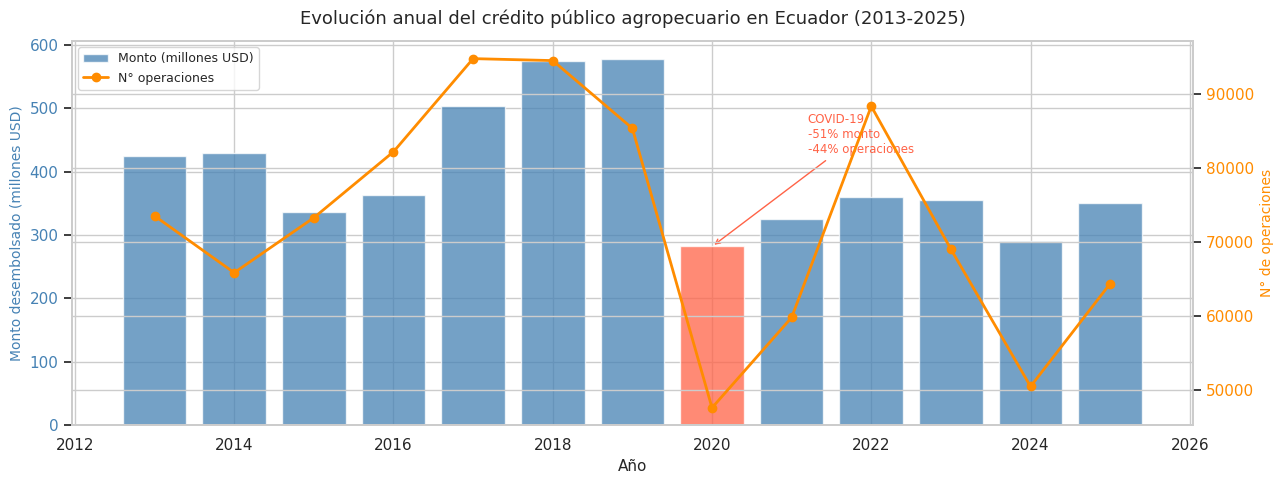

In [10]:
# ============================================================
# GRÁFICO: EVOLUCIÓN ANUAL DEL CRÉDITO (MONTO + OPERACIONES)
# ============================================================

fig, ax1 = plt.subplots(figsize=(13, 5))

# --- Barras: monto total en millones ---
# Coloreamos 2020 de rojo para destacar el impacto COVID visualmente
colores = ["tomato" if anio == 2020 else "steelblue"
           for anio in credito_anual["CP_ANIO"]]  # lista de colores por año

ax1.bar(
    credito_anual["CP_ANIO"],
    credito_anual["monto_millones"],
    color=colores,       # aplicamos la lista de colores (rojo en 2020, azul resto)
    alpha=0.75,
    label="Monto (millones USD)"
)
ax1.set_xlabel("Año", fontsize=11)
ax1.set_ylabel("Monto desembolsado (millones USD)", color="steelblue", fontsize=10)
ax1.tick_params(axis="y", labelcolor="steelblue")

# Anotación explicativa sobre la barra de 2020
# annotate() agrega texto con flecha apuntando a un punto del gráfico
ax1.annotate(
    "COVID-19\n-51% monto\n-44% operaciones",  # texto de la anotación
    xy=(2020, 282),          # punto al que apunta la flecha (año, valor)
    xytext=(2021.2, 430),    # posición del texto
    fontsize=8.5,
    color="tomato",
    arrowprops=dict(arrowstyle="->", color="tomato")  # flecha roja
)

# --- Línea: número de operaciones ---
ax2 = ax1.twinx()  # segundo eje Y a la derecha
ax2.plot(
    credito_anual["CP_ANIO"],
    credito_anual["num_operaciones"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="N° operaciones"
)
ax2.set_ylabel("N° de operaciones", color="darkorange", fontsize=10)
ax2.tick_params(axis="y", labelcolor="darkorange")

# Título y leyendas unificadas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()  # leyenda del eje izquierdo
lines2, labels2 = ax2.get_legend_handles_labels()  # leyenda del eje derecho
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=9)  # combinamos ambas en una sola leyenda

plt.title(
    "Evolución anual del crédito público agropecuario en Ecuador (2013-2025)",
    fontsize=13, pad=12
)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# PASO 3: EDA — BLOQUE 2: DISTRIBUCIÓN GEOGRÁFICA
# ============================================================

# --- 3.3 CRÉDITO TOTAL POR PROVINCIA (monto y operaciones) ---

# Agrupamos por provincia y calculamos monto total y número de operaciones
# Usamos df_mag completo (2013-2025) para reflejar el acumulado histórico
credito_provincia = df_mag.groupby("DPA_DESPRO").agg(
    monto_total=("CP_VALOR_USD", "sum"),           # suma total de USD
    num_operaciones=("CP_NUM_OPERACIONES", "sum"), # suma total de operaciones
    num_registros=("CP_VALOR_USD", "count")        # número de filas (registros)
).reset_index()

# Convertimos monto a millones para mejor lectura
credito_provincia["monto_millones"] = credito_provincia["monto_total"] / 1_000_000

# Calculamos el monto promedio por operación en USD
# Esto nos dice si una provincia recibe créditos grandes o pequeños
credito_provincia["promedio_por_op"] = (
    credito_provincia["monto_total"] / credito_provincia["num_operaciones"]
).round(0)

# Ordenamos de mayor a menor monto para el gráfico
credito_provincia = credito_provincia.sort_values(
    "monto_millones", ascending=False
).reset_index(drop=True)

print("=== CRÉDITO ACUMULADO POR PROVINCIA (2013-2025) ===")
print(credito_provincia[["DPA_DESPRO", "monto_millones",
                          "num_operaciones", "promedio_por_op"]
                        ].to_string(index=False))

=== CRÉDITO ACUMULADO POR PROVINCIA (2013-2025) ===
                    DPA_DESPRO  monto_millones  num_operaciones  promedio_por_op
                        Guayas      560.330613           103111           5434.0
                      Los Ríos      538.962365           105756           5096.0
                        Manabí      535.659572           111242           4815.0
                          Loja      440.678473            92967           4740.0
                    Chimborazo      333.011402            76491           4354.0
                    Esmeraldas      299.748222            27651          10840.0
                      Cotopaxi      279.631230            48027           5822.0
                     Pichincha      237.539889            33269           7140.0
                        Carchi      196.339205            26327           7458.0
               Morona Santiago      191.609960            35065           5464.0
                    Tungurahua      180.292567           

In [12]:
# --- 3.4 CONCENTRACIÓN GEOGRÁFICA: ¿CUÁNTO ACAPARAN LAS TOP PROVINCIAS? ---

# Calculamos qué porcentaje del crédito total acumula cada provincia
monto_total_pais = credito_provincia["monto_millones"].sum()

credito_provincia["pct_del_total"] = (
    credito_provincia["monto_millones"] / monto_total_pais * 100
).round(1)

# Calculamos el acumulado progresivo (cuánto suman las top N provincias juntas)
# cumsum() suma acumulada: va sumando cada fila a las anteriores
credito_provincia["pct_acumulado"] = credito_provincia["pct_del_total"].cumsum().round(1)

print("=== CONCENTRACIÓN GEOGRÁFICA DEL CRÉDITO ===")
print(credito_provincia[["DPA_DESPRO", "monto_millones",
                          "pct_del_total", "pct_acumulado"]].to_string(index=False))

=== CONCENTRACIÓN GEOGRÁFICA DEL CRÉDITO ===
                    DPA_DESPRO  monto_millones  pct_del_total  pct_acumulado
                        Guayas      560.330613           10.8           10.8
                      Los Ríos      538.962365           10.4           21.2
                        Manabí      535.659572           10.4           31.6
                          Loja      440.678473            8.5           40.1
                    Chimborazo      333.011402            6.4           46.5
                    Esmeraldas      299.748222            5.8           52.3
                      Cotopaxi      279.631230            5.4           57.7
                     Pichincha      237.539889            4.6           62.3
                        Carchi      196.339205            3.8           66.1
               Morona Santiago      191.609960            3.7           69.8
                    Tungurahua      180.292567            3.5           73.3
                       Bolívar 

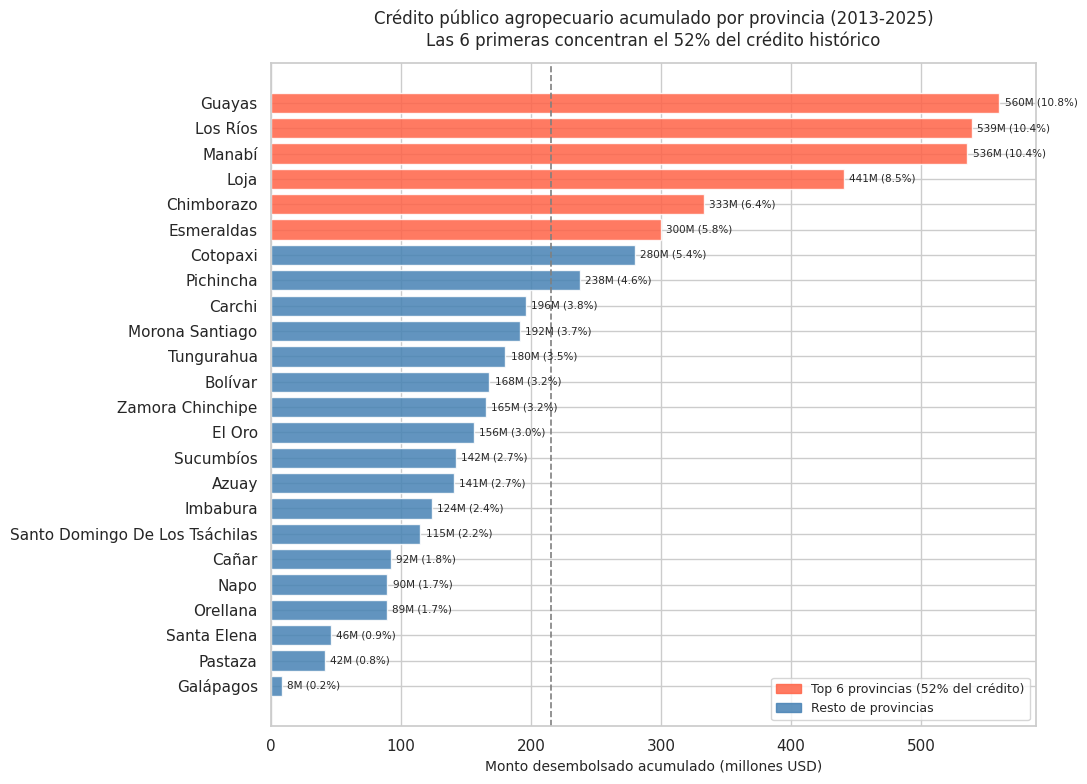

In [13]:
# ============================================================
# GRÁFICO: CRÉDITO ACUMULADO POR PROVINCIA (2013-2025)
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))

# Ordenamos ascendente para que la barra más grande quede arriba
provincias_ord = credito_provincia.sort_values("monto_millones", ascending=True)

# Coloreamos las top 6 provincias de un color distinto
# para destacar visualmente la concentración del crédito
colores = [
    "tomato" if p in credito_provincia.head(6)["DPA_DESPRO"].values
    else "steelblue"
    for p in provincias_ord["DPA_DESPRO"]
]

# barh() dibuja barras horizontales
ax.barh(
    provincias_ord["DPA_DESPRO"],
    provincias_ord["monto_millones"],
    color=colores,
    alpha=0.85
)

# Etiqueta al final de cada barra con el monto y el porcentaje del total
for i, row in enumerate(provincias_ord.itertuples()):
    ax.text(
        row.monto_millones + 4,  # posición X: justo después de la barra
        i,                        # posición Y: altura de la barra
        f"{row.monto_millones:.0f}M ({row.pct_del_total}%)",
        va="center",
        fontsize=7.5
    )

# Línea vertical punteada en el promedio simple entre provincias
# para visualizar cuáles están por encima y cuáles por debajo
promedio = credito_provincia["monto_millones"].mean()
ax.axvline(
    x=promedio,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Promedio: {promedio:.0f}M"
)

# Leyenda manual para explicar los colores
from matplotlib.patches import Patch
leyenda = [
    Patch(color="tomato", alpha=0.85, label="Top 6 provincias (52% del crédito)"),
    Patch(color="steelblue", alpha=0.85, label="Resto de provincias"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=9)

ax.set_xlabel("Monto desembolsado acumulado (millones USD)", fontsize=10)
ax.set_title(
    "Crédito público agropecuario acumulado por provincia (2013-2025)\n"
    "Las 6 primeras concentran el 52% del crédito histórico",
    fontsize=12, pad=12
)
plt.tight_layout()
plt.show()

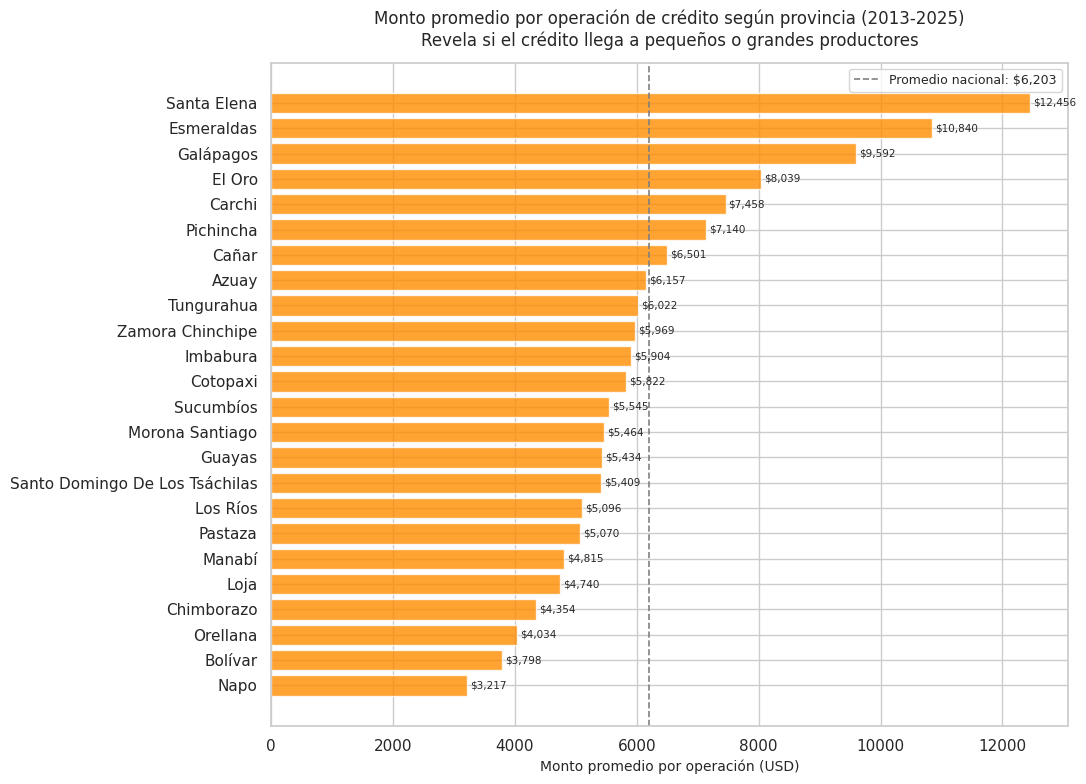

In [14]:
# ============================================================
# CRÉDITO PROMEDIO POR OPERACIÓN: ¿CRÉDITOS GRANDES O PEQUEÑOS?
# ============================================================

# Este gráfico revela si una provincia recibe pocos créditos grandes
# o muchos créditos pequeños — clave para entender el perfil de cada territorio

fig, ax = plt.subplots(figsize=(11, 8))

prom_ord = credito_provincia.sort_values("promedio_por_op", ascending=True)

ax.barh(
    prom_ord["DPA_DESPRO"],
    prom_ord["promedio_por_op"],
    color="darkorange",
    alpha=0.8
)

# Etiqueta con el valor exacto en USD
for i, row in enumerate(prom_ord.itertuples()):
    ax.text(
        row.promedio_por_op + 50,
        i,
        f"${row.promedio_por_op:,.0f}",
        va="center",
        fontsize=7.5
    )

# Línea del promedio nacional
promedio_nac = credito_provincia["promedio_por_op"].mean()
ax.axvline(
    x=promedio_nac,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Promedio nacional: ${promedio_nac:,.0f}"
)
ax.legend(fontsize=9)

ax.set_xlabel("Monto promedio por operación (USD)", fontsize=10)
ax.set_title(
    "Monto promedio por operación de crédito según provincia (2013-2025)\n"
    "Revela si el crédito llega a pequeños o grandes productores",
    fontsize=12, pad=12
)
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# PASO 3: EDA — BLOQUE 3: ANÁLISIS POR SECTOR Y PRODUCTO
# ============================================================

# --- 3.5 CRÉDITO POR SECTOR PRODUCTIVO ---

# Agrupamos por sector (Agrícola, Pecuario, Otros)
# para entender a qué actividades va el crédito público
credito_sector = df_mag.groupby("CP_SECTOR").agg(
    monto_total=("CP_VALOR_USD", "sum"),
    num_operaciones=("CP_NUM_OPERACIONES", "sum")
).reset_index()

# Calculamos porcentaje del total para cada sector
credito_sector["monto_millones"] = credito_sector["monto_total"] / 1_000_000
credito_sector["pct_monto"] = (
    credito_sector["monto_millones"] /
    credito_sector["monto_millones"].sum() * 100
).round(1)

# Ordenamos de mayor a menor
credito_sector = credito_sector.sort_values("monto_millones", ascending=False)

print("=== CRÉDITO POR SECTOR PRODUCTIVO ===")
print(credito_sector[["CP_SECTOR", "monto_millones",
                       "pct_monto", "num_operaciones"]].to_string(index=False))

=== CRÉDITO POR SECTOR PRODUCTIVO ===
CP_SECTOR  monto_millones  pct_monto  num_operaciones
 Pecuario     2297.832261       44.4           500451
 Agrícola     1945.491070       37.6           374789
    Otros      863.387994       16.7            72620
Silvícola       64.125103        1.2              872
 Acuícola        1.927926        0.0              231


In [16]:
# --- 3.6 TOP 15 PRODUCTOS MÁS FINANCIADOS ---

# Agrupamos por producto homologado (categoría limpia)
# para ver qué cultivos/actividades reciben más crédito
credito_producto = df_mag.groupby("CP_PRODUCTO_HOMOLOGADO").agg(
    monto_total=("CP_VALOR_USD", "sum"),
    num_operaciones=("CP_NUM_OPERACIONES", "sum")
).reset_index()

credito_producto["monto_millones"] = credito_producto["monto_total"] / 1_000_000
credito_producto["pct_monto"] = (
    credito_producto["monto_millones"] /
    credito_producto["monto_millones"].sum() * 100
).round(1)
credito_producto["promedio_op"] = (
    credito_producto["monto_total"] /
    credito_producto["num_operaciones"]
).round(0)

# Ordenamos y tomamos los 15 productos con mayor monto
top15_productos = credito_producto.sort_values(
    "monto_millones", ascending=False
).head(15).reset_index(drop=True)

print("=== TOP 15 PRODUCTOS MÁS FINANCIADOS (2013-2025) ===")
print(top15_productos[["CP_PRODUCTO_HOMOLOGADO", "monto_millones",
                        "pct_monto", "num_operaciones",
                        "promedio_op"]].to_string(index=False))

=== TOP 15 PRODUCTOS MÁS FINANCIADOS (2013-2025) ===
                    CP_PRODUCTO_HOMOLOGADO  monto_millones  pct_monto  num_operaciones  promedio_op
                 Ganado De Doble Propósito      505.727121        9.8            57166       8847.0
                           Ganado De Leche      463.022102        9.0           101198       4575.0
                           Ganado De Carne      338.372740        6.5            62315       5430.0
                          Porcinos De Cría      335.296913        6.5            91658       3658.0
                                      Maíz      298.863701        5.8           115910       2578.0
                                     Cacao      235.591172        4.6            56380       4179.0
           Compra De Abonos Y Agroquímicos      181.112681        3.5            37084       4884.0
Construcciones Para Adecuaciones Agrícolas      170.570507        3.3            12960      13161.0
                            Palma Aceitera     

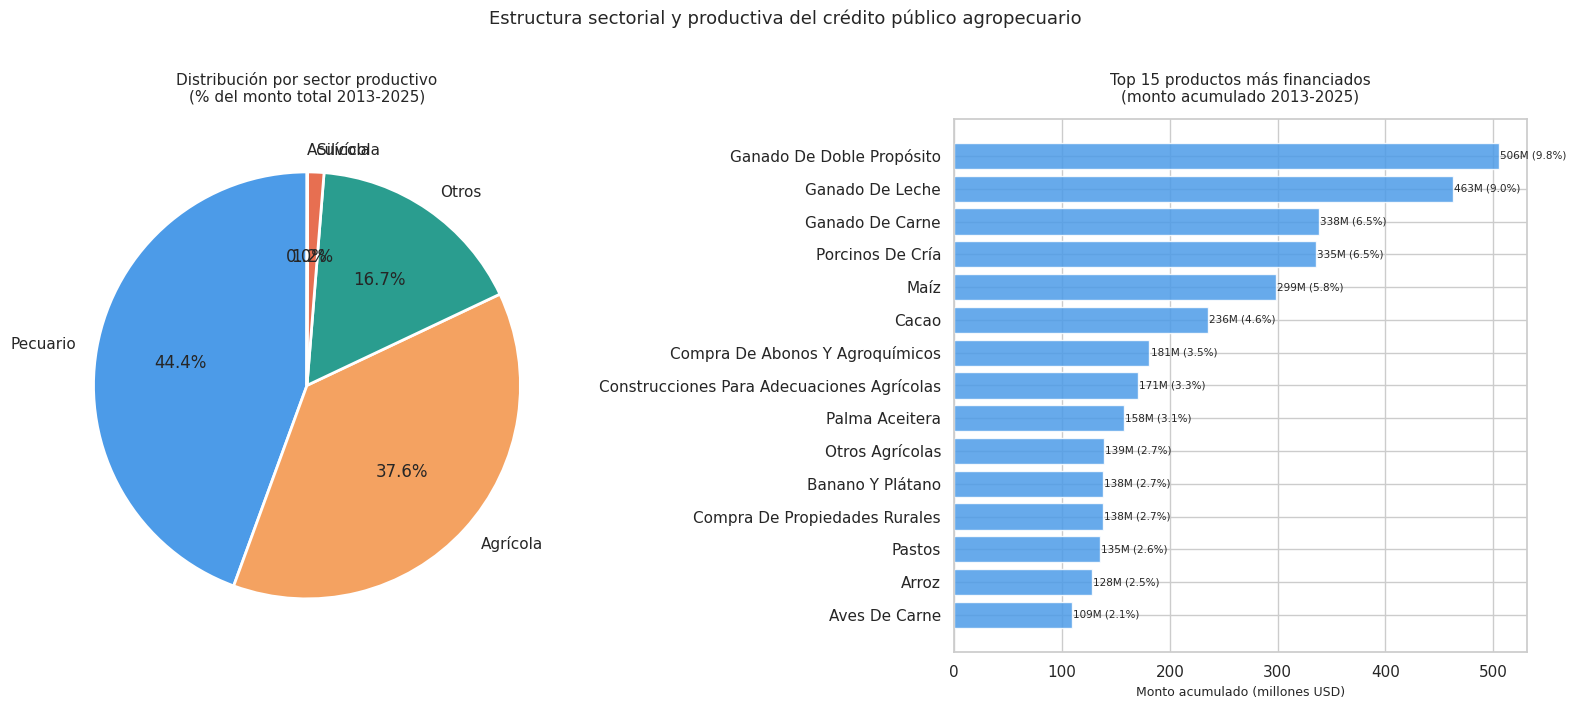

In [17]:
# Gráfico combinado: sectores (pie) + top productos (barras)
# Usamos subplots para poner los dos gráficos lado a lado

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Gráfico izquierdo: PIE de sectores ---
# autopct muestra el porcentaje dentro de cada porción
ax1.pie(
    credito_sector["monto_millones"],       # tamaño de cada porción
    labels=credito_sector["CP_SECTOR"],     # etiqueta de cada sector
    autopct="%1.1f%%",                      # formato del porcentaje
    startangle=90,                          # ángulo de inicio
    colors=["#4C9BE8", "#F4A261", "#2A9D8F", "#E76F51"],  # colores
    wedgeprops={"edgecolor": "white", "linewidth": 2}     # borde blanco entre porciones
)
ax1.set_title("Distribución por sector productivo\n(% del monto total 2013-2025)",
              fontsize=11, pad=12)

# --- Gráfico derecho: BARRAS HORIZONTALES top 15 productos ---
top15_ord = top15_productos.sort_values("monto_millones", ascending=True)

ax2.barh(
    top15_ord["CP_PRODUCTO_HOMOLOGADO"],
    top15_ord["monto_millones"],
    color="#4C9BE8",
    alpha=0.85
)

# Etiqueta con monto y porcentaje al final de cada barra
for i, row in enumerate(top15_ord.itertuples()):
    ax2.text(
        row.monto_millones + 1,
        i,
        f"{row.monto_millones:.0f}M ({row.pct_monto}%)",
        va="center",
        fontsize=7.5
    )

ax2.set_xlabel("Monto acumulado (millones USD)", fontsize=9)
ax2.set_title("Top 15 productos más financiados\n(monto acumulado 2013-2025)",
              fontsize=11, pad=12)

plt.suptitle(
    "Estructura sectorial y productiva del crédito público agropecuario",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# PASO 3: EDA — BLOQUE 4: ANÁLISIS DE BRECHA DE GÉNERO
# VERSIÓN ROBUSTA: funciona aunque el CSV incluya años nuevos
# ============================================================

df_personas = df_mag[
    (df_mag["CP_GENERO"].isin(["Femenino", "Masculino"])) &
    (df_mag["CP_ANIO"] < 2026)   # doble seguridad
].copy()

print(f"✅ df_personas recreado correctamente")
print(f"Filas: {len(df_personas):,}")
print(f"Años disponibles: {sorted(df_personas['CP_ANIO'].unique())}")
# --- 3.7 CRÉDITO TOTAL POR GÉNERO ---
# Usamos df_personas ya creado (solo Femenino y Masculino, sin 2026)
credito_genero = df_personas.groupby("CP_GENERO").agg(
    monto_total=("CP_VALOR_USD", "sum"),
    num_operaciones=("CP_NUM_OPERACIONES", "sum"),
    num_registros=("CP_VALOR_USD", "count")
).reset_index()

credito_genero["monto_millones"] = credito_genero["monto_total"] / 1_000_000
credito_genero["pct_monto"] = (
    credito_genero["monto_millones"] /
    credito_genero["monto_millones"].sum() * 100
).round(1)
credito_genero["promedio_op"] = (
    credito_genero["monto_total"] /
    credito_genero["num_operaciones"]
).round(0)

print("=== CRÉDITO TOTAL POR GÉNERO (2013-2025) ===")
print(credito_genero[["CP_GENERO", "monto_millones",
                       "pct_monto", "num_operaciones",
                       "promedio_op"]].to_string(index=False))

✅ df_personas recreado correctamente
Filas: 283,775
Años disponibles: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
=== CRÉDITO TOTAL POR GÉNERO (2013-2025) ===
CP_GENERO  monto_millones  pct_monto  num_operaciones  promedio_op
 Femenino     1653.998015       37.2           551326       3000.0
Masculino     2791.625241       62.8           387794       7199.0


In [19]:
# --- 3.8 EVOLUCIÓN ANUAL (excluye 2026 explícitamente) ---
# IMPORTANTE: filtramos < 2026 para que no entre el año incompleto
genero_anual = df_personas[df_personas["CP_ANIO"] < 2026].groupby(
    ["CP_ANIO", "CP_GENERO"]
).agg(
    monto_total=("CP_VALOR_USD", "sum"),
    num_operaciones=("CP_NUM_OPERACIONES", "sum")
).reset_index()

genero_anual["monto_millones"] = genero_anual["monto_total"] / 1_000_000

genero_pivot = genero_anual.pivot_table(
    index="CP_ANIO",
    columns="CP_GENERO",
    values="monto_millones",
    aggfunc="sum"
).reset_index()

genero_pivot["ratio_M_F"] = (
    genero_pivot["Masculino"] / genero_pivot["Femenino"]
).round(2)

genero_pivot["pct_femenino"] = (
    genero_pivot["Femenino"] /
    (genero_pivot["Femenino"] + genero_pivot["Masculino"]) * 100
).round(1)

print("\n=== EVOLUCIÓN ANUAL DE LA BRECHA DE GÉNERO ===")
print(genero_pivot[["CP_ANIO", "Femenino", "Masculino",
                     "ratio_M_F", "pct_femenino"]].to_string(index=False))


=== EVOLUCIÓN ANUAL DE LA BRECHA DE GÉNERO ===
 CP_ANIO   Femenino  Masculino  ratio_M_F  pct_femenino
    2013  96.257053 225.365937       2.34          29.9
    2014  80.934148 171.338187       2.12          32.1
    2015  93.293586 178.931072       1.92          34.3
    2016 104.368228 201.366507       1.93          34.1
    2017 142.661874 293.105035       2.05          32.7
    2018 164.663991 339.146916       2.06          32.7
    2019 177.966816 340.092717       1.91          34.4
    2020  88.073345 154.778942       1.76          36.3
    2021 119.391186 164.610800       1.38          42.0
    2022 150.717243 199.302838       1.32          43.1
    2023 147.708217 198.552004       1.34          42.7
    2024 121.491475 155.624211       1.28          43.8
    2025 166.470853 169.410075       1.02          49.6


In [20]:
# --- 3.9 BRECHA POR PROVINCIA (excluye 2026 explícitamente) ---
genero_provincia = df_personas[df_personas["CP_ANIO"] < 2026].groupby(
    ["DPA_DESPRO", "CP_GENERO"]
).agg(
    monto_total=("CP_VALOR_USD", "sum"),
    num_operaciones=("CP_NUM_OPERACIONES", "sum")
).reset_index()

genero_provincia["monto_millones"] = genero_provincia["monto_total"] / 1_000_000

genero_prov_pivot = genero_provincia.pivot_table(
    index="DPA_DESPRO",
    columns="CP_GENERO",
    values="monto_millones",
    aggfunc="sum"
).reset_index()

genero_prov_pivot["pct_femenino"] = (
    genero_prov_pivot["Femenino"] /
    (genero_prov_pivot["Femenino"] + genero_prov_pivot["Masculino"]) * 100
).round(1)

genero_prov_pivot["ratio_M_F"] = (
    genero_prov_pivot["Masculino"] / genero_prov_pivot["Femenino"]
).round(2)

genero_prov_pivot = genero_prov_pivot.sort_values(
    "pct_femenino", ascending=True
).reset_index(drop=True)

print("\n=== BRECHA DE GÉNERO POR PROVINCIA ===")
print(genero_prov_pivot[["DPA_DESPRO", "Femenino", "Masculino",
                          "pct_femenino", "ratio_M_F"]].to_string(index=False))

# --- Variables para la anotación dinámica del gráfico ---
# Siempre toma el último año COMPLETO disponible (no 2026)
ultimo_anio = genero_pivot["CP_ANIO"].max()
ultimo_pct  = genero_pivot[
    genero_pivot["CP_ANIO"] == ultimo_anio
]["pct_femenino"].values[0]
anio_texto  = ultimo_anio - 3

print(f"\nÚltimo año completo: {ultimo_anio} | % femenino: {ultimo_pct}%")
print("✅ Todos los objetos de género creados correctamente")


=== BRECHA DE GÉNERO POR PROVINCIA ===
                    DPA_DESPRO   Femenino  Masculino  pct_femenino  ratio_M_F
                        El Oro  36.914825 102.083032          26.6       2.77
                        Manabí 142.081108 346.146711          29.1       2.44
                        Carchi  60.013392 127.971338          31.9       2.13
                      Imbabura  35.639547  71.956091          33.1       2.02
                   Santa Elena   4.227907   8.400917          33.5       1.99
                          Loja 145.037311 273.626717          34.6       1.89
                    Esmeraldas  76.737401 144.172495          34.7       1.88
Santo Domingo De Los Tsáchilas  35.130717  63.791644          35.5       1.82
                     Sucumbíos  52.169709  89.483201          36.8       1.72
              Zamora Chinchipe  61.714463 102.843428          37.5       1.67
                        Guayas 145.490349 242.060663          37.5       1.66
                      Co

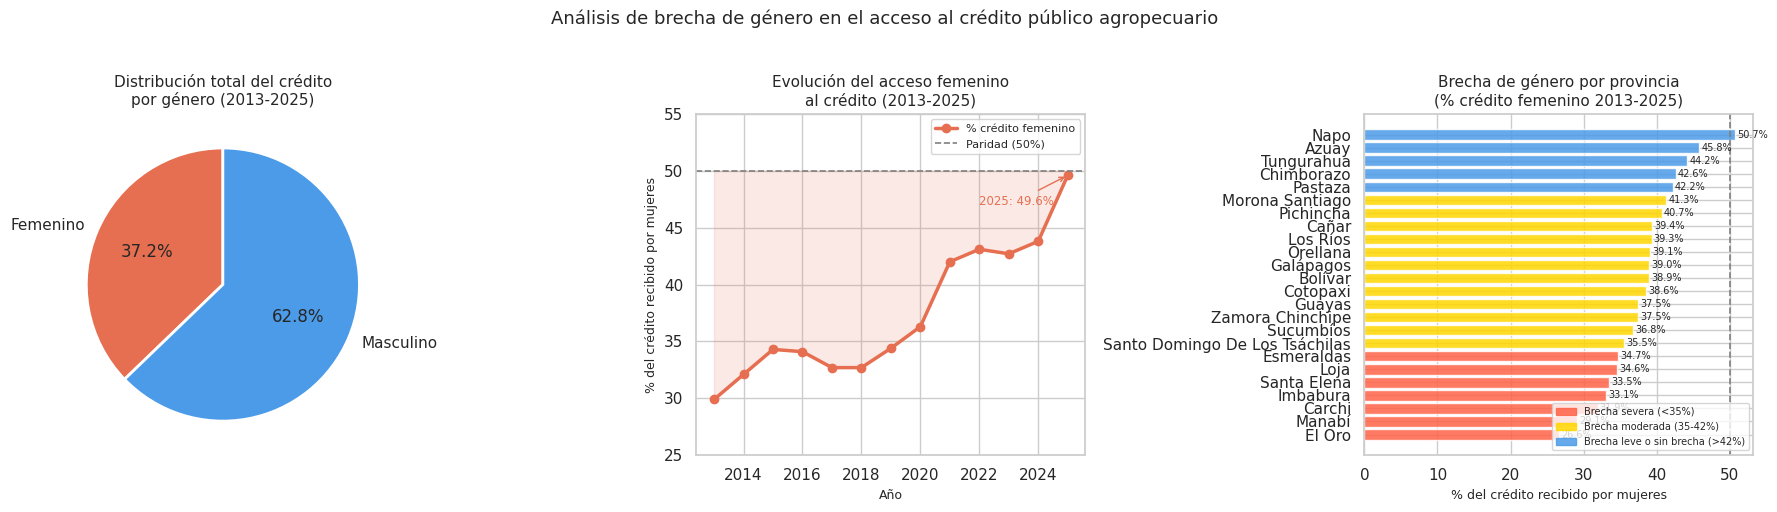

✅ Gráfico de género guardado


In [21]:
# ============================================================
# GRÁFICOS: ANÁLISIS DE BRECHA DE GÉNERO
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: PIE de distribución total por género ---
ax1 = axes[0]
ax1.pie(
    credito_genero["monto_millones"],
    labels=credito_genero["CP_GENERO"],
    autopct="%1.1f%%",
    colors=["#E76F51", "#4C9BE8"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax1.set_title("Distribución total del crédito\npor género (2013-2025)", fontsize=11)

# --- GRÁFICO 2: LÍNEA de evolución del % femenino por año ---
ax2 = axes[1]

ax2.plot(
    genero_pivot["CP_ANIO"],
    genero_pivot["pct_femenino"],
    color="#E76F51",
    marker="o",
    linewidth=2.5,
    label="% crédito femenino"
)

ax2.axhline(
    y=50, color="gray", linestyle="--",
    linewidth=1.2, label="Paridad (50%)"
)

ax2.fill_between(
    genero_pivot["CP_ANIO"],
    genero_pivot["pct_femenino"],
    50, alpha=0.15, color="#E76F51"
)

# Anotación dinámica: último año disponible en el pivot
ax2.annotate(
    f"{ultimo_anio}: {ultimo_pct}%",
    xy=(ultimo_anio, ultimo_pct),
    xytext=(anio_texto, 47),
    fontsize=8.5,
    color="#E76F51",
    arrowprops=dict(arrowstyle="->", color="#E76F51")
)

ax2.set_xlabel("Año", fontsize=9)
ax2.set_ylabel("% del crédito recibido por mujeres", fontsize=9)
ax2.set_title("Evolución del acceso femenino\nal crédito (2013-2025)", fontsize=11)
ax2.legend(fontsize=8)
ax2.set_ylim(25, 55)

# --- GRÁFICO 3: BARRAS HORIZONTALES de % femenino por provincia ---
ax3 = axes[2]

prov_ord = genero_prov_pivot.sort_values("pct_femenino", ascending=True)

colores = [
    "tomato" if p < 35 else
    "gold"   if p < 42 else
    "#4C9BE8"
    for p in prov_ord["pct_femenino"]
]

ax3.barh(
    prov_ord["DPA_DESPRO"],
    prov_ord["pct_femenino"],
    color=colores,
    alpha=0.85
)

ax3.axvline(x=50, color="gray", linestyle="--", linewidth=1.2)

for i, row in enumerate(prov_ord.itertuples()):
    ax3.text(
        row.pct_femenino + 0.3, i,
        f"{row.pct_femenino}%",
        va="center", fontsize=7
    )

from matplotlib.patches import Patch
leyenda = [
    Patch(color="tomato",  alpha=0.85, label="Brecha severa (<35%)"),
    Patch(color="gold",    alpha=0.85, label="Brecha moderada (35-42%)"),
    Patch(color="#4C9BE8", alpha=0.85, label="Brecha leve o sin brecha (>42%)"),
]
ax3.legend(handles=leyenda, fontsize=7, loc="lower right")
ax3.set_xlabel("% del crédito recibido por mujeres", fontsize=9)
ax3.set_title("Brecha de género por provincia\n(% crédito femenino 2013-2025)",
              fontsize=11)

plt.suptitle(
    "Análisis de brecha de género en el acceso al crédito público agropecuario",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("genero_analisis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Gráfico de género guardado")

In [22]:
# ============================================================
# PASO 4: CRUCE CON NBI — PREPARACIÓN
# ============================================================

# Cargamos el dataset NBI (ya lo teníamos cargado como df_nbi,
# pero lo recargamos por si el kernel se reinició)
df_nbi = pd.read_csv("nbi_canton_2010_2022.csv")

print("=== NBI CARGADO ===")
print("Filas x columnas:", df_nbi.shape)
print("\nPrimeras 3 filas:")
print(df_nbi.head(3).to_string())

=== NBI CARGADO ===
Filas x columnas: (221, 7)

Primeras 3 filas:
         provincia    canton  pobres_2010_n  pobres_2022_n  pct_nbi_2010  pct_nbi_2022  variacion_pct
0  Morona Santiago    Taisha          17648          25856         0.985         0.969          -0.02
1           Manabí    Olmedo           9631           9440         0.974         0.936          -0.04
2  Morona Santiago  Tiwintza           6219           8656         0.959         0.934          -0.03


In [23]:
# ============================================================
# AGREGAMOS EL DATASET MAG A NIVEL DE PROVINCIA
# para poder cruzarlo con el NBI (que también está a nivel provincia)
# ============================================================

# Agrupamos el MAG por provincia con las métricas que necesitamos para el cruce
mag_provincia = df_mag.groupby("DPA_DESPRO").agg(
    monto_total=("CP_VALOR_USD", "sum"),           # monto acumulado total
    num_operaciones=("CP_NUM_OPERACIONES", "sum"), # operaciones acumuladas
    num_cantones=("DPA_DESCAN", "nunique")         # cuántos cantones distintos atendidos
).reset_index()

# Convertimos a millones para mejor lectura
mag_provincia["monto_millones"] = mag_provincia["monto_total"] / 1_000_000

# Calculamos el monto promedio por operación a nivel provincia
mag_provincia["promedio_op"] = (
    mag_provincia["monto_total"] / mag_provincia["num_operaciones"]
).round(0)

print("=== MAG AGREGADO POR PROVINCIA ===")
print("Filas:", len(mag_provincia))
print(mag_provincia[["DPA_DESPRO", "monto_millones",
                      "num_operaciones", "num_cantones"]].to_string(index=False))

=== MAG AGREGADO POR PROVINCIA ===
Filas: 24
                    DPA_DESPRO  monto_millones  num_operaciones  num_cantones
                         Azuay      140.967958            22895            15
                       Bolívar      167.987491            44225             7
                        Carchi      196.339205            26327             6
                         Cañar       92.197653            14181             7
                    Chimborazo      333.011402            76491            10
                      Cotopaxi      279.631230            48027             7
                        El Oro      156.300886            19442            14
                    Esmeraldas      299.748222            27651             8
                     Galápagos        8.182170              853             3
                        Guayas      560.330613           103111            25
                      Imbabura      123.891870            20986             6
                   

In [24]:
# ============================================================
# PREPARAMOS EL NBI A NIVEL DE PROVINCIA
# El NBI que tenemos está a nivel cantón, lo agregamos a provincia
# ============================================================

# Agrupamos el NBI por provincia calculando el promedio ponderado del NBI
# Usamos como peso la población total de cada cantón (pobres + no pobres en 2022)
# porque no es lo mismo promediar un cantón de 500 personas que uno de 500.000

# Primero calculamos la población total de cada cantón en 2022
df_nbi["pob_total_2022"] = (
    df_nbi["pobres_2022_n"] / df_nbi["pct_nbi_2022"]
).round(0)  # población total = pobres / proporción de pobres

# Agrupamos por provincia calculando NBI promedio ponderado por población
nbi_provincia = df_nbi.groupby("provincia").apply(
    lambda g: pd.Series({
        # NBI 2022 ponderado: suma(NBI_canton * pob_canton) / suma(pob_canton)
        "nbi_2022_pond": (
            (g["pct_nbi_2022"] * g["pob_total_2022"]).sum() /
            g["pob_total_2022"].sum()
        ).round(3),
        # NBI 2010 ponderado: igual pero con datos del censo anterior
        "nbi_2010_pond": (
            (g["pct_nbi_2010"] * g["pob_total_2022"]).sum() /
            g["pob_total_2022"].sum()
        ).round(3),
        # Número de cantones en la provincia
        "num_cantones_nbi": len(g)
    })
).reset_index()

# Calculamos la variación del NBI entre censos a nivel provincial
nbi_provincia["variacion_nbi"] = (
    nbi_provincia["nbi_2022_pond"] - nbi_provincia["nbi_2010_pond"]
).round(3)

print("=== NBI AGREGADO POR PROVINCIA ===")
print(nbi_provincia.sort_values("nbi_2022_pond",
                                 ascending=False).to_string(index=False))

=== NBI AGREGADO POR PROVINCIA ===
                     provincia  nbi_2022_pond  nbi_2010_pond  num_cantones_nbi  variacion_nbi
                      Orellana          0.687          0.848               4.0         -0.161
               Morona Santiago          0.654          0.756              12.0         -0.102
                    Esmeraldas          0.629          0.771               7.0         -0.142
                          Napo          0.617          0.785               5.0         -0.168
                      Los Ríos          0.614          0.792              13.0         -0.178
                        Manabí          0.601          0.766              22.0         -0.165
                     Sucumbíos          0.592          0.868               7.0         -0.276
                       Bolívar          0.585          0.762               7.0         -0.177
                       Pastaza          0.530          0.696               4.0         -0.166
              Zamora Chin

/tmp/ipykernel_5000/3037564006.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  nbi_provincia = df_nbi.groupby("provincia").apply(


In [25]:
# ============================================================
# PASO 4: CRUCE MAG + NBI — EL HALLAZGO CENTRAL DEL TFM
# ============================================================

# Corregimos el warning de pandas añadiendo include_groups=False
nbi_provincia = df_nbi.groupby("provincia").apply(
    lambda g: pd.Series({
        "nbi_2022_pond": (
            (g["pct_nbi_2022"] * g["pob_total_2022"]).sum() /
            g["pob_total_2022"].sum()
        ).round(3),
        "nbi_2010_pond": (
            (g["pct_nbi_2010"] * g["pob_total_2022"]).sum() /
            g["pob_total_2022"].sum()
        ).round(3),
        "num_cantones_nbi": len(g),
        "variacion_nbi": (
            (g["pct_nbi_2022"] * g["pob_total_2022"]).sum() /
            g["pob_total_2022"].sum() -
            (g["pct_nbi_2010"] * g["pob_total_2022"]).sum() /
            g["pob_total_2022"].sum()
        ).round(3)
    }),
    include_groups=False  # excluye la columna de agrupación para evitar el warning
).reset_index()

print("✅ NBI provincial recalculado sin warnings")
print("Provincias:", len(nbi_provincia))

✅ NBI provincial recalculado sin warnings
Provincias: 24


In [26]:
# ============================================================
# NORMALIZAMOS LOS NOMBRES DE PROVINCIA ANTES DEL CRUCE
# para que coincidan exactamente entre los dos datasets
# ============================================================

# Revisamos cómo se llaman las provincias en cada dataset
print("=== NOMBRES EN MAG ===")
print(sorted(mag_provincia["DPA_DESPRO"].unique()))

print("\n=== NOMBRES EN NBI ===")
print(sorted(nbi_provincia["provincia"].unique()))

=== NOMBRES EN MAG ===
['Azuay', 'Bolívar', 'Carchi', 'Cañar', 'Chimborazo', 'Cotopaxi', 'El Oro', 'Esmeraldas', 'Galápagos', 'Guayas', 'Imbabura', 'Loja', 'Los Ríos', 'Manabí', 'Morona Santiago', 'Napo', 'Orellana', 'Pastaza', 'Pichincha', 'Santa Elena', 'Santo Domingo De Los Tsáchilas', 'Sucumbíos', 'Tungurahua', 'Zamora Chinchipe']

=== NOMBRES EN NBI ===
['Azuay', 'Bolívar', 'Carchi', 'Cañar', 'Chimborazo', 'Cotopaxi', 'El Oro', 'Esmeraldas', 'Galápagos', 'Guayas', 'Imbabura', 'Loja', 'Los Ríos', 'Manabí', 'Morona Santiago', 'Napo', 'Orellana', 'Pastaza', 'Pichincha', 'Santa Elena', 'Santo Domingo De Los Tsáchilas', 'Sucumbíos', 'Tungurahua', 'Zamora Chinchipe']


In [27]:
# Creamos un diccionario para estandarizar los nombres
# que puedan diferir entre los dos datasets
# (tildes, mayúsculas, abreviaciones distintas)
mapeo_nombres = {
    # Formato en MAG : Formato en NBI
    "Morona Santiago"                  : "Morona Santiago",
    "Santo Domingo De Los Tsáchilas"   : "Santo Domingo De Los Tsáchilas",
    "Zamora Chinchipe"                 : "Zamora Chinchipe",
}
# Aplicamos el mapeo al dataset MAG (por si acaso hay diferencias)
# Si los nombres ya coinciden, el mapeo no cambia nada
mag_provincia["provincia_std"] = mag_provincia["DPA_DESPRO"].replace(mapeo_nombres)

# Hacemos el cruce (merge) entre MAG y NBI por nombre de provincia
# how="inner" conserva solo las provincias que existen en ambos datasets
df_cruce = pd.merge(
    mag_provincia,                          # dataset izquierdo: crédito MAG
    nbi_provincia,                          # dataset derecho: pobreza NBI
    left_on="provincia_std",               # columna de unión en MAG
    right_on="provincia",                  # columna de unión en NBI
    how="inner"                            # solo provincias presentes en ambos
)

print("✅ Cruce realizado")
print("Provincias en el cruce:", len(df_cruce))
print("\nProvincias que NO cruzaron (si las hay):")
print(set(mag_provincia["DPA_DESPRO"]) - set(df_cruce["DPA_DESPRO"]))

✅ Cruce realizado
Provincias en el cruce: 24

Provincias que NO cruzaron (si las hay):
set()


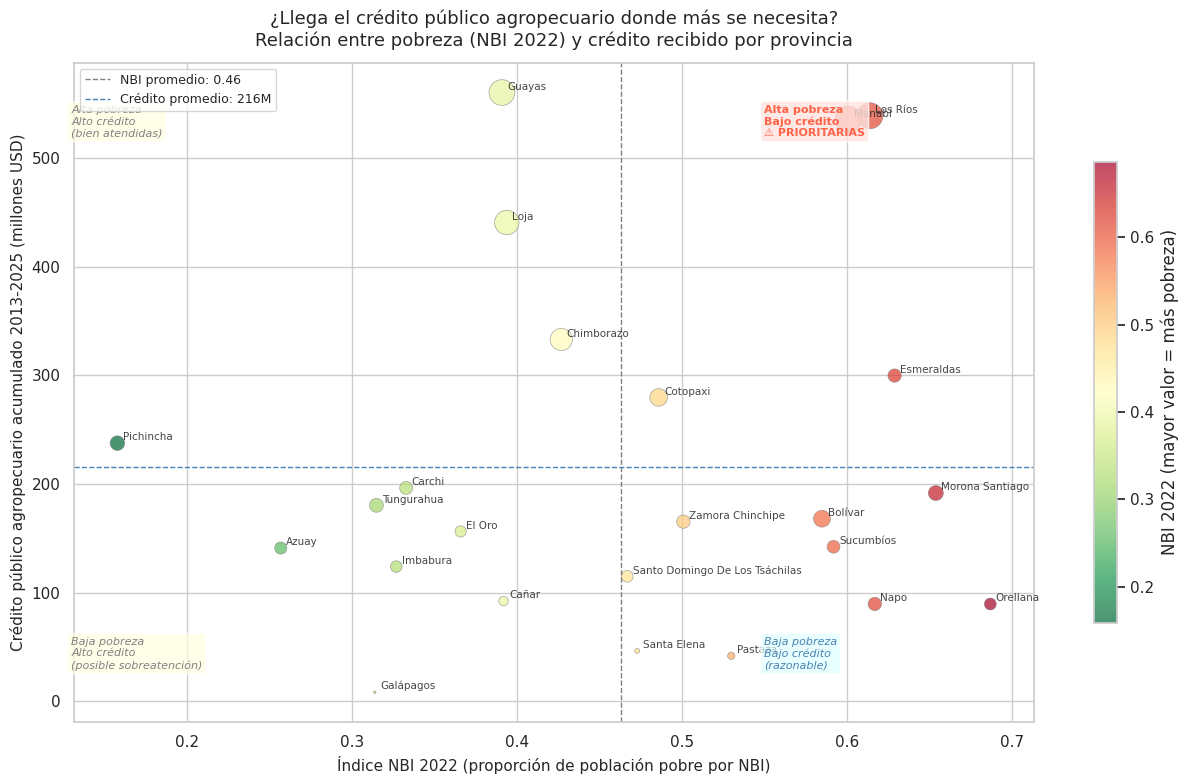

In [28]:
# ============================================================
# GRÁFICO CENTRAL: DISPERSIÓN CRÉDITO vs POBREZA POR PROVINCIA
# ============================================================

fig, ax = plt.subplots(figsize=(13, 8))

# Dibujamos un punto por provincia
# Eje X: NBI 2022 (nivel de pobreza)
# Eje Y: monto de crédito en millones USD
# Tamaño del punto: número de operaciones (más operaciones = punto más grande)
scatter = ax.scatter(
    df_cruce["nbi_2022_pond"],     # eje X: pobreza
    df_cruce["monto_millones"],    # eje Y: crédito
    s=df_cruce["num_operaciones"] / 300,  # tamaño del punto proporcional a operaciones
    alpha=0.7,
    c=df_cruce["nbi_2022_pond"],   # color también refleja el NBI (más rojo = más pobre)
    cmap="RdYlGn_r",               # escala: rojo para pobres, verde para menos pobres
    edgecolors="gray",
    linewidth=0.5
)

# Añadimos el nombre de cada provincia junto a su punto
for _, row in df_cruce.iterrows():
    ax.annotate(
        row["DPA_DESPRO"],           # texto: nombre de la provincia
        xy=(row["nbi_2022_pond"], row["monto_millones"]),  # posición del punto
        xytext=(4, 2),               # desplazamiento del texto respecto al punto
        textcoords="offset points",  # el desplazamiento es en puntos tipográficos
        fontsize=7.5,
        alpha=0.85
    )

# Líneas de referencia en los promedios para crear los 4 cuadrantes
nbi_medio = df_cruce["nbi_2022_pond"].mean()
credito_medio = df_cruce["monto_millones"].mean()

# Línea vertical: NBI promedio
ax.axvline(
    x=nbi_medio,
    color="gray", linestyle="--", linewidth=1,
    label=f"NBI promedio: {nbi_medio:.2f}"
)

# Línea horizontal: crédito promedio
ax.axhline(
    y=credito_medio,
    color="steelblue", linestyle="--", linewidth=1,
    label=f"Crédito promedio: {credito_medio:.0f}M"
)

# Etiquetas de los 4 cuadrantes
ax.text(0.13, 520, "Alta pobreza\nAlto crédito\n(bien atendidas)",
        fontsize=8, color="gray", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.7))

ax.text(0.55, 520, "Alta pobreza\nBajo crédito\n⚠ PRIORITARIAS",
        fontsize=8, color="tomato", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="mistyrose", alpha=0.8))

ax.text(0.13, 30, "Baja pobreza\nAlto crédito\n(posible sobreatención)",
        fontsize=8, color="gray", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.7))

ax.text(0.55, 30, "Baja pobreza\nBajo crédito\n(razonable)",
        fontsize=8, color="steelblue", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcyan", alpha=0.7))

# Barra de color para interpretar el NBI
plt.colorbar(scatter, ax=ax, label="NBI 2022 (mayor valor = más pobreza)", shrink=0.7)

ax.set_xlabel("Índice NBI 2022 (proporción de población pobre por NBI)", fontsize=11)
ax.set_ylabel("Crédito público agropecuario acumulado 2013-2025 (millones USD)", fontsize=11)
ax.set_title(
    "¿Llega el crédito público agropecuario donde más se necesita?\n"
    "Relación entre pobreza (NBI 2022) y crédito recibido por provincia",
    fontsize=13, pad=12
)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# PASO 4: MÉTRICA DE BRECHA DE ATENCIÓN
# Cuantifica qué tan bien o mal atendida está cada provincia
# en relación a su nivel de pobreza
# ============================================================

# Calculamos el crédito per cápita ponderado por pobreza
# La lógica es: una provincia pobre debería recibir MÁS crédito per cápita
# que una provincia rica para compensar sus desventajas estructurales

# Paso 1: estimamos la población total de cada provincia
# usando los datos del NBI (pobres_2022_n / pct_nbi_2022 = población total)
df_nbi["pob_total_2022"] = (
    df_nbi["pobres_2022_n"] / df_nbi["pct_nbi_2022"]
).round(0)

# Agregamos la población total a nivel provincial
pob_provincia = df_nbi.groupby("provincia")["pob_total_2022"].sum().reset_index()
pob_provincia.columns = ["provincia", "pob_total_provincia"]

# Añadimos la población al dataset de cruce
df_cruce = pd.merge(df_cruce, pob_provincia, on="provincia", how="left")

# Paso 2: calculamos el crédito per cápita (USD por habitante)
df_cruce["credito_per_capita"] = (
    df_cruce["monto_total"] / df_cruce["pob_total_provincia"]
).round(2)

# Paso 3: calculamos el ÍNDICE DE BRECHA DE ATENCIÓN
# Fórmula: NBI / crédito_per_capita normalizado
# Provincias con NBI alto y crédito per cápita bajo → índice alto → más prioritarias

# Normalizamos ambas variables entre 0 y 1 para hacerlas comparables
# MinMaxScaler transforma cualquier rango de valores al rango [0, 1]
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()  # creamos el normalizador

# Normalizamos NBI 2022 (ya está entre 0 y 1 pero lo reescalamos al rango del conjunto)
df_cruce["nbi_norm"] = scaler.fit_transform(
    df_cruce[["nbi_2022_pond"]]  # doble corchete porque fit_transform espera 2D
)

# Normalizamos el crédito per cápita (invertido: más crédito = menor prioridad)
# Usamos 1 - valor para invertirlo: quien recibe menos crédito tiene valor más alto
df_cruce["credito_pc_norm_inv"] = 1 - scaler.fit_transform(
    df_cruce[["credito_per_capita"]]
)

# Índice de brecha = promedio de NBI normalizado y crédito per cápita invertido
# Valor alto → provincia pobre Y poco atendida → máxima prioridad
df_cruce["indice_brecha"] = (
    (df_cruce["nbi_norm"] + df_cruce["credito_pc_norm_inv"]) / 2
).round(3)

# Ordenamos de mayor a menor brecha (las más prioritarias arriba)
ranking = df_cruce.sort_values("indice_brecha", ascending=False).reset_index(drop=True)
ranking.index += 1  # el ranking empieza en 1, no en 0

print("=== RANKING DE PRIORIZACIÓN TERRITORIAL ===")
print("(Mayor índice = más pobre Y menos atendida = más prioritaria)\n")
print(ranking[["DPA_DESPRO", "nbi_2022_pond", "credito_per_capita",
               "monto_millones", "indice_brecha"]].to_string())

=== RANKING DE PRIORIZACIÓN TERRITORIAL ===
(Mayor índice = más pobre Y menos atendida = más prioritaria)

                        DPA_DESPRO  nbi_2022_pond  credito_per_capita  monto_millones  indice_brecha
1                         Orellana          0.687              491.61       89.432139          0.854
2                           Manabí          0.601              336.99      535.659572          0.827
3                      Santa Elena          0.473              120.39       46.325091          0.782
4                       Esmeraldas          0.629              544.31      299.748222          0.781
5                         Los Ríos          0.614              600.76      538.962365          0.747
6                          Pastaza          0.530              374.60       41.764215          0.747
7   Santo Domingo De Los Tsáchilas          0.467              233.74      114.936812          0.737
8                             Napo          0.617              683.14       89.524990

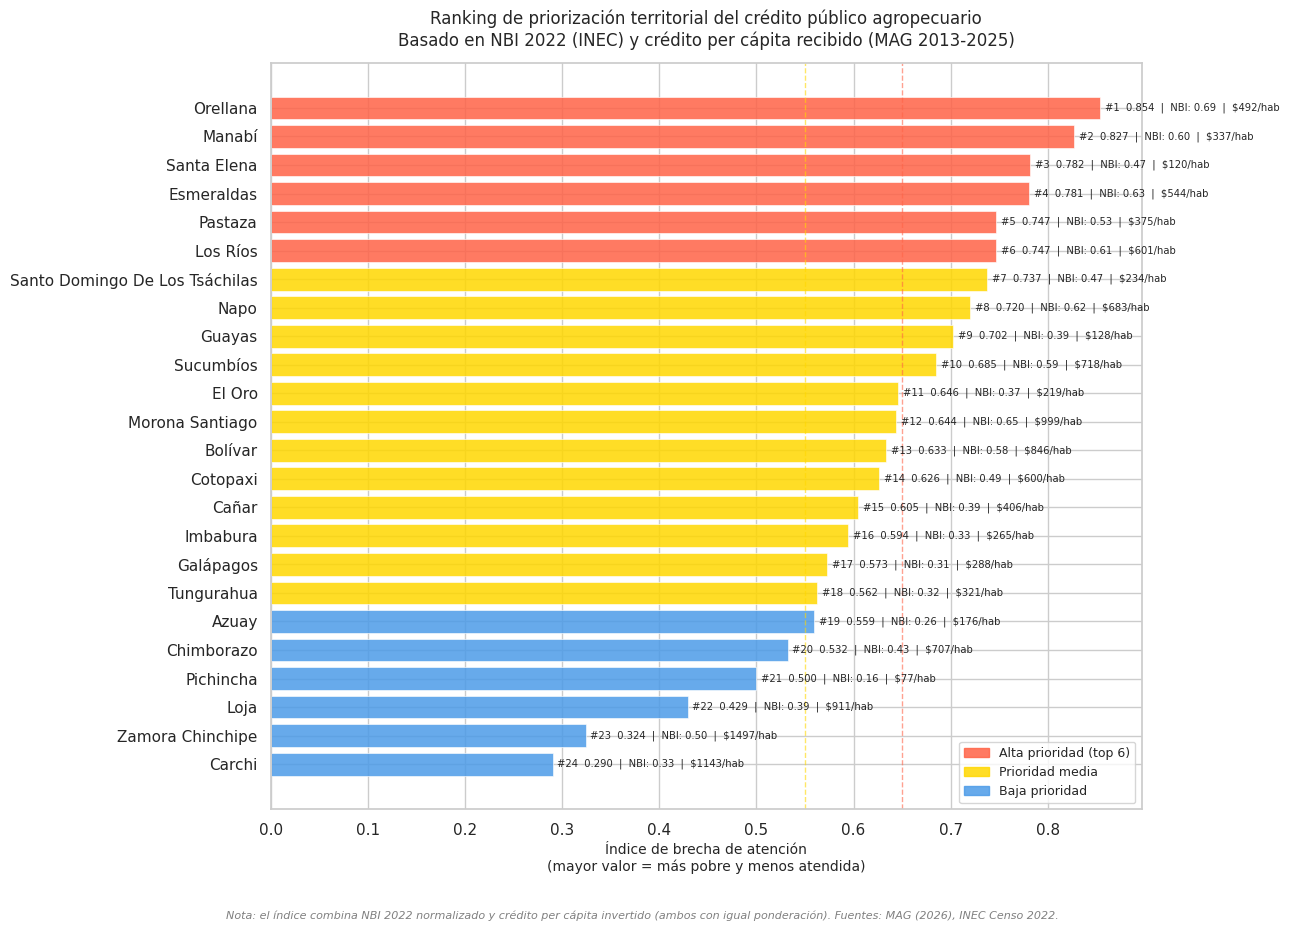

✅ Gráfico guardado como 'ranking_priorizacion_territorial.png'


In [30]:
# ============================================================
# GRÁFICO: RANKING DE PRIORIZACIÓN TERRITORIAL
# ============================================================

fig, ax = plt.subplots(figsize=(13, 9))

ranking_grafico = ranking.sort_values("indice_brecha", ascending=True)

# Calculamos los colores
colores_grafico = [
    "tomato"   if (24 - i) <= 6  else
    "gold"     if (24 - i) <= 18 else
    "#4C9BE8"
    for i in range(len(ranking_grafico))
]

ax.barh(
    ranking_grafico["DPA_DESPRO"],
    ranking_grafico["indice_brecha"],
    color=colores_grafico,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5
)

for i, row in enumerate(ranking_grafico.itertuples()):
    pos = 24 - i
    ax.text(
        row.indice_brecha + 0.005,
        i,
        f"#{pos}  {row.indice_brecha:.3f}  |  NBI: {row.nbi_2022_pond:.2f}  |  "
        f"${row.credito_per_capita:.0f}/hab",
        va="center",
        fontsize=7.2
    )

ax.axvline(x=0.65, color="tomato", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(x=0.55, color="gold",   linestyle="--", linewidth=1, alpha=0.6)

from matplotlib.patches import Patch
leyenda = [
    Patch(color="tomato",  alpha=0.85, label="Alta prioridad (top 6)"),
    Patch(color="gold",    alpha=0.85, label="Prioridad media"),
    Patch(color="#4C9BE8", alpha=0.85, label="Baja prioridad"),
]
ax.legend(handles=leyenda, fontsize=9, loc="lower right")

ax.set_xlabel(
    "Índice de brecha de atención\n(mayor valor = más pobre y menos atendida)",
    fontsize=10
)
ax.set_title(
    "Ranking de priorización territorial del crédito público agropecuario\n"
    "Basado en NBI 2022 (INEC) y crédito per cápita recibido (MAG 2013-2025)",
    fontsize=12, pad=12
)

fig.text(
    0.5, -0.03,
    "Nota: el índice combina NBI 2022 normalizado y crédito per cápita invertido "
    "(ambos con igual ponderación). Fuentes: MAG (2026), INEC Censo 2022.",
    ha="center", fontsize=8, color="gray", style="italic"
)

plt.tight_layout()
plt.savefig("ranking_priorizacion_territorial.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Gráfico guardado como 'ranking_priorizacion_territorial.png'")

In [31]:
# ============================================================
# TABLA RESUMEN PARA LA MEMORIA
# ============================================================

print("=== TABLA FINAL PARA LA MEMORIA ===\n")
print(f"{'#':<4} {'Provincia':<35} {'NBI 2022':>8} {'Créd/hab':>10} "
      f"{'Monto (M)':>10} {'Índice':>8} {'Prioridad':<12}")
print("-" * 95)

for i, row in ranking.iterrows():
    if i <= 6:
        prioridad = "🔴 Alta"
    elif i <= 18:
        prioridad = "🟡 Media"
    else:
        prioridad = "🟢 Baja"

    print(f"{i:<4} {row['DPA_DESPRO']:<35} {row['nbi_2022_pond']:>8.3f} "
          f"{row['credito_per_capita']:>10.1f} {row['monto_millones']:>10.1f} "
          f"{row['indice_brecha']:>8.3f} {prioridad:<12}")

=== TABLA FINAL PARA LA MEMORIA ===

#    Provincia                           NBI 2022   Créd/hab  Monto (M)   Índice Prioridad   
-----------------------------------------------------------------------------------------------
1    Orellana                               0.687      491.6       89.4    0.854 🔴 Alta      
2    Manabí                                 0.601      337.0      535.7    0.827 🔴 Alta      
3    Santa Elena                            0.473      120.4       46.3    0.782 🔴 Alta      
4    Esmeraldas                             0.629      544.3      299.7    0.781 🔴 Alta      
5    Los Ríos                               0.614      600.8      539.0    0.747 🔴 Alta      
6    Pastaza                                0.530      374.6       41.8    0.747 🔴 Alta      
7    Santo Domingo De Los Tsáchilas         0.467      233.7      114.9    0.737 🟡 Media     
8    Napo                                   0.617      683.1       89.5    0.720 🟡 Media     
9    Guayas          

**CLUSTERING**

In [32]:
# ============================================================
# PASO 5: CLUSTERING DE PROVINCIAS
# ============================================================

# Importamos las librerías necesarias para clustering
from sklearn.cluster import KMeans          # algoritmo K-Means
from sklearn.preprocessing import StandardScaler  # normalización de variables
from sklearn.metrics import silhouette_score      # métrica para evaluar clusters

# --- 5.1 PREPARAMOS LAS VARIABLES PARA EL CLUSTERING ---

# Seleccionamos las variables que describen el perfil de cada provincia
# Usamos el dataset df_cruce que ya tiene MAG + NBI juntos
features = df_cruce[[
    "nbi_2022_pond",        # nivel de pobreza actual
    "variacion_nbi",        # velocidad de reducción de pobreza 2010-2022
    "credito_per_capita",   # crédito per cápita recibido
    "monto_millones",       # volumen total de crédito
    "promedio_op",          # tamaño promedio de los créditos (pequeños vs grandes)
    "indice_brecha"         # índice de brecha calculado antes
]].copy()

# Guardamos los nombres de provincia para etiquetar los clusters después
nombres = df_cruce["DPA_DESPRO"].values

print("=== VARIABLES PARA EL CLUSTERING ===")
print(features.describe().round(3).to_string())

=== VARIABLES PARA EL CLUSTERING ===
       nbi_2022_pond  variacion_nbi  credito_per_capita  monto_millones  promedio_op  indice_brecha
count         24.000         24.000              24.000          24.000       24.000         24.000
mean           0.463         -0.207             528.589         215.532     6203.167          0.629
std            0.141          0.047             359.349         160.285     2186.167          0.145
min            0.158         -0.288              76.920           8.182     3217.000          0.290
25%            0.358         -0.244             256.878         109.252     5006.250          0.561
50%            0.470         -0.207             448.895         166.641     5683.500          0.639
75%            0.594         -0.172             709.695         284.660     6660.750          0.740
max            0.687         -0.102            1496.540         560.331    12456.000          0.854


In [33]:
# --- 5.2 NORMALIZAMOS LAS VARIABLES ---

# El clustering usa distancias entre puntos
# Si una variable va de 0 a 1 y otra de 0 a 1500, la segunda domina injustamente
# StandardScaler lleva todas las variables a media=0 y desviación=1
# así todas tienen el mismo peso en el cálculo de distancias

scaler_cluster = StandardScaler()

# fit_transform: aprende la media y desviación de cada columna (fit)
# y luego transforma los datos (transform)
features_scaled = scaler_cluster.fit_transform(features)

print("✅ Variables normalizadas")
print("Media de cada variable después de normalizar (debe ser ~0):")
print(features_scaled.mean(axis=0).round(3))
print("\nDesviación estándar (debe ser ~1):")
print(features_scaled.std(axis=0).round(3))

✅ Variables normalizadas
Media de cada variable después de normalizar (debe ser ~0):
[ 0.  0. -0.  0. -0. -0.]

Desviación estándar (debe ser ~1):
[1. 1. 1. 1. 1. 1.]


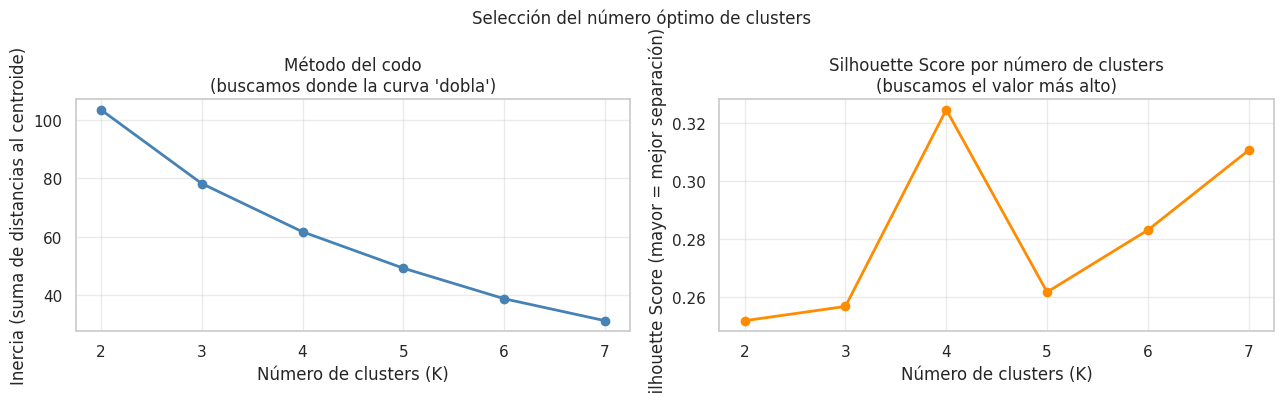


=== VALORES EXACTOS ===
K=2  |  Inercia: 103.5  |  Silhouette: 0.252
K=3  |  Inercia: 78.3  |  Silhouette: 0.257
K=4  |  Inercia: 61.8  |  Silhouette: 0.325
K=5  |  Inercia: 49.3  |  Silhouette: 0.262
K=6  |  Inercia: 38.9  |  Silhouette: 0.283
K=7  |  Inercia: 31.4  |  Silhouette: 0.311


In [34]:
# --- 5.3 ELEGIMOS EL NÚMERO ÓPTIMO DE CLUSTERS ---

# Usamos dos métodos para decidir cuántos clusters hacer:
# 1) Método del codo: busca dónde la inercia deja de bajar mucho
# 2) Silhouette score: mide qué tan bien separados están los clusters (más alto = mejor)

inercias = []        # almacena la inercia de cada K
silhouettes = []     # almacena el silhouette score de cada K
rango_k = range(2, 8)  # probamos de 2 a 7 clusters

for k in rango_k:
    # Ejecutamos K-Means con k clusters
    # random_state=42 garantiza que el resultado sea reproducible
    # n_init=10 ejecuta el algoritmo 10 veces y queda con el mejor resultado
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)  # ajustamos el modelo a los datos normalizados

    inercias.append(kmeans.inertia_)  # suma de distancias al centroide (menor = mejor)
    silhouettes.append(
        silhouette_score(features_scaled, kmeans.labels_)  # calidad de separación
    )

# Graficamos los dos métodos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- Gráfico del codo ---
ax1.plot(rango_k, inercias, marker="o", color="steelblue", linewidth=2)
ax1.set_xlabel("Número de clusters (K)")
ax1.set_ylabel("Inercia (suma de distancias al centroide)")
ax1.set_title("Método del codo\n(buscamos donde la curva 'dobla')")
ax1.grid(True, alpha=0.4)

# --- Gráfico de silhouette ---
ax2.plot(rango_k, silhouettes, marker="o", color="darkorange", linewidth=2)
ax2.set_xlabel("Número de clusters (K)")
ax2.set_ylabel("Silhouette Score (mayor = mejor separación)")
ax2.set_title("Silhouette Score por número de clusters\n(buscamos el valor más alto)")
ax2.grid(True, alpha=0.4)

plt.suptitle("Selección del número óptimo de clusters", fontsize=12)
plt.tight_layout()
plt.show()

# Mostramos los valores exactos para facilitar la decisión
print("\n=== VALORES EXACTOS ===")
for k, inercia, sil in zip(rango_k, inercias, silhouettes):
    print(f"K={k}  |  Inercia: {inercia:.1f}  |  Silhouette: {sil:.3f}")

In [35]:
# ============================================================
# PASO 5: CLUSTERING FINAL CON K=4
# ============================================================

# Ejecutamos K-Means con 4 clusters, que fue el K óptimo
# según el silhouette score (0.325) y el método del codo
kmeans_final = KMeans(
    n_clusters=4,      # número de grupos elegido
    random_state=42,   # semilla para reproducibilidad
    n_init=10          # ejecuta 10 veces y queda con el mejor resultado
)

# Ajustamos el modelo a los datos normalizados
kmeans_final.fit(features_scaled)

# Añadimos la etiqueta del cluster a cada provincia en el dataset
df_cruce["cluster"] = kmeans_final.labels_

print("✅ Clustering ejecutado con K=4")
print("\n=== PROVINCIAS POR CLUSTER ===")
for cluster_id in sorted(df_cruce["cluster"].unique()):
    provincias = df_cruce[df_cruce["cluster"] == cluster_id]["DPA_DESPRO"].tolist()
    print(f"\nCluster {cluster_id}: {provincias}")

✅ Clustering ejecutado con K=4

=== PROVINCIAS POR CLUSTER ===

Cluster 0: ['Bolívar', 'Esmeraldas', 'Morona Santiago', 'Napo', 'Orellana', 'Pastaza']

Cluster 1: ['Azuay', 'Cañar', 'Cotopaxi', 'El Oro', 'Galápagos', 'Imbabura', 'Pichincha', 'Santa Elena', 'Santo Domingo De Los Tsáchilas', 'Sucumbíos', 'Tungurahua']

Cluster 2: ['Carchi', 'Chimborazo', 'Loja', 'Zamora Chinchipe']

Cluster 3: ['Guayas', 'Los Ríos', 'Manabí']


In [36]:
# --- 5.4 PERFIL DE CADA CLUSTER ---

# Calculamos la media de cada variable por cluster
# Esto nos dice qué caracteriza a cada grupo
perfil_clusters = df_cruce.groupby("cluster")[
    ["nbi_2022_pond", "variacion_nbi", "credito_per_capita",
     "monto_millones", "promedio_op", "indice_brecha"]
].mean().round(3)

print("=== PERFIL PROMEDIO DE CADA CLUSTER ===")
print(perfil_clusters.to_string())

=== PERFIL PROMEDIO DE CADA CLUSTER ===
         nbi_2022_pond  variacion_nbi  credito_per_capita  monto_millones  promedio_op  indice_brecha
cluster                                                                                              
0                0.617         -0.152             656.403         146.678     5403.833          0.730
1                0.377         -0.240             311.303         138.402     7144.273          0.624
2                0.414         -0.221            1064.428         283.831     5630.250          0.394
3                0.535         -0.178             355.223         544.984     5115.000          0.759


In [37]:
# ============================================================
# ASIGNAMOS NOMBRES INTERPRETABLES A LOS CLUSTERS
# basados en el perfil económico de cada grupo
# ============================================================

nombres_clusters = {
    0: "Periféricas sub-atendidas\n(alta pobreza, bajo volumen)",
    1: "Relativamente desarrolladas\n(baja pobreza, buen avance)",
    2: "Bien servidas\n(crédito per cápita alto)",
    3: "Densamente pobladas\n(alto volumen, dilución per cápita)"
}

# Aplicamos los nombres al dataset
df_cruce["cluster_nombre"] = df_cruce["cluster"].map(nombres_clusters)

print("✅ Clusters nombrados")
print("\n=== CLUSTERS CON NOMBRES ===")
for cluster_id in sorted(df_cruce["cluster"].unique()):
    nombre = nombres_clusters[cluster_id]
    provincias = df_cruce[df_cruce["cluster"] == cluster_id]["DPA_DESPRO"].tolist()
    indice_prom = df_cruce[df_cruce["cluster"] == cluster_id]["indice_brecha"].mean()
    print(f"\n{'─'*55}")
    print(f"Cluster {cluster_id}: {nombre.replace(chr(10), ' ')}")
    print(f"Índice brecha promedio: {indice_prom:.3f}")
    print(f"Provincias: {', '.join(provincias)}")

✅ Clusters nombrados

=== CLUSTERS CON NOMBRES ===

───────────────────────────────────────────────────────
Cluster 0: Periféricas sub-atendidas (alta pobreza, bajo volumen)
Índice brecha promedio: 0.730
Provincias: Bolívar, Esmeraldas, Morona Santiago, Napo, Orellana, Pastaza

───────────────────────────────────────────────────────
Cluster 1: Relativamente desarrolladas (baja pobreza, buen avance)
Índice brecha promedio: 0.624
Provincias: Azuay, Cañar, Cotopaxi, El Oro, Galápagos, Imbabura, Pichincha, Santa Elena, Santo Domingo De Los Tsáchilas, Sucumbíos, Tungurahua

───────────────────────────────────────────────────────
Cluster 2: Bien servidas (crédito per cápita alto)
Índice brecha promedio: 0.394
Provincias: Carchi, Chimborazo, Loja, Zamora Chinchipe

───────────────────────────────────────────────────────
Cluster 3: Densamente pobladas (alto volumen, dilución per cápita)
Índice brecha promedio: 0.759
Provincias: Guayas, Los Ríos, Manabí


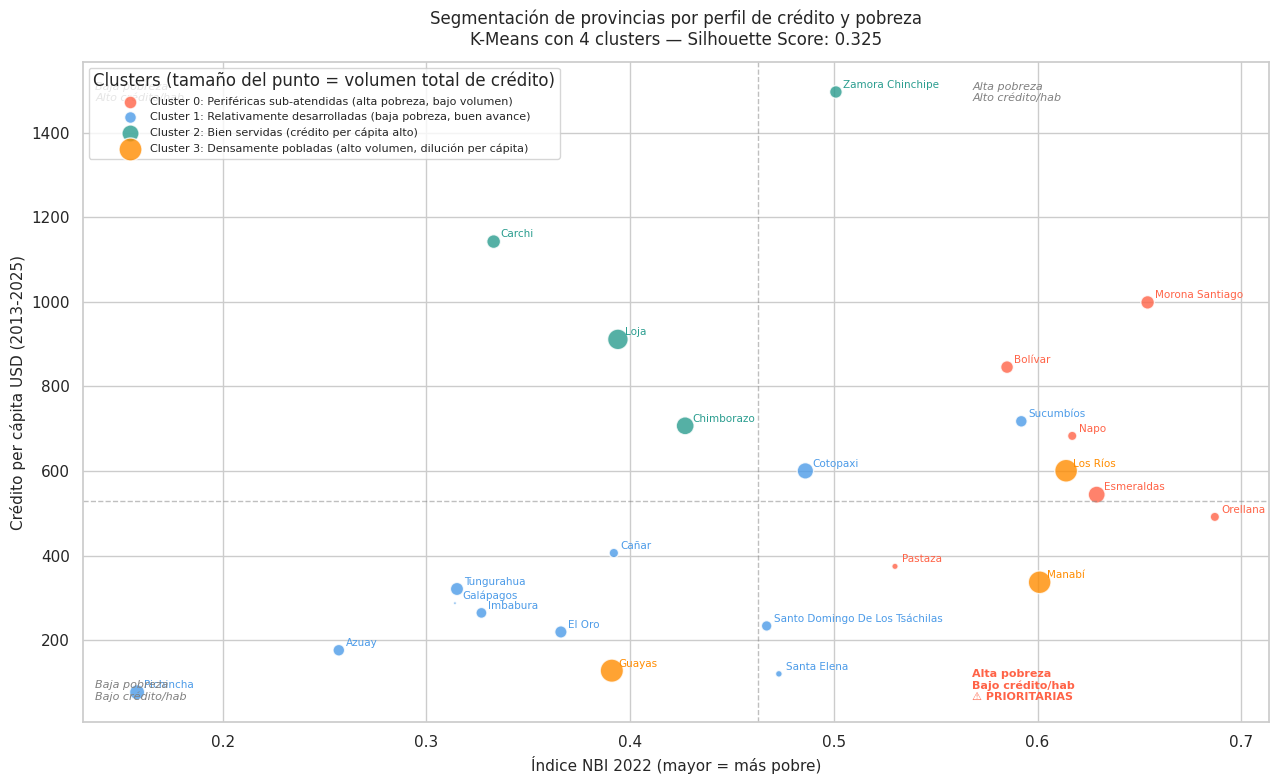

In [38]:
# ============================================================
# GRÁFICO: DISPERSIÓN CON CLUSTERS COLOREADOS
# Crédito per cápita vs NBI 2022, coloreado por cluster
# ============================================================

# Definimos colores y nombres aquí para no depender de bloques anteriores
colores_cluster = {
    0: "tomato",
    1: "#4C9BE8",
    2: "#2A9D8F",
    3: "darkorange"
}

nombres_clusters = {
    0: "Periféricas sub-atendidas\n(alta pobreza, bajo volumen)",
    1: "Relativamente desarrolladas\n(baja pobreza, buen avance)",
    2: "Bien servidas\n(crédito per cápita alto)",
    3: "Densamente pobladas\n(alto volumen, dilución per cápita)"
}

fig, ax = plt.subplots(figsize=(13, 8))

# Dibujamos un punto por provincia
# Eje X: NBI 2022 (nivel de pobreza)
# Eje Y: monto de crédito en millones USD
# Tamaño del punto: número de operaciones (más operaciones = punto más grande)
for cluster_id in sorted(df_cruce["cluster"].unique()):
    subset = df_cruce[df_cruce["cluster"] == cluster_id]
    nombre_limpio = nombres_clusters[cluster_id].replace("\n", " ")

    ax.scatter(
        subset["nbi_2022_pond"],        # eje X: pobreza
        subset["credito_per_capita"],   # eje Y: crédito
        s=subset["monto_millones"] / 2,  # tamaño del punto proporcional a operaciones
        color=colores_cluster[cluster_id],
        alpha=0.8,
        edgecolors="white",
        linewidth=1,
        label=f"Cluster {cluster_id}: {nombre_limpio}"
    )

    # Añadimos el nombre de cada provincia junto a su punto
    for _, row in subset.iterrows():
        ax.annotate(
            row["DPA_DESPRO"],           # texto: nombre de la provincia
            xy=(row["nbi_2022_pond"], row["credito_per_capita"]),  # posición del punto
            xytext=(5, 3),               # desplazamiento del texto respecto al punto
            textcoords="offset points",  # el desplazamiento es en puntos tipográficos
            fontsize=7.5,
            color=colores_cluster[cluster_id]
        )

# Líneas de referencia en los promedios para crear los 4 cuadrantes
ax.axvline(x=df_cruce["nbi_2022_pond"].mean(),
           color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.axhline(y=df_cruce["credito_per_capita"].mean(),
           color="gray", linestyle="--", linewidth=1, alpha=0.5)

# Etiquetas de los 4 cuadrantes
# usando transform=ax.transAxes para posición relativa al área del gráfico
# (0,0) = esquina inferior izquierda, (1,1) = esquina superior derecha
ax.text(
    0.01, 0.97,                    # esquina superior izquierda
    "Baja pobreza\nAlto crédito/hab",
    transform=ax.transAxes,        # coordenadas relativas al gráfico (0 a 1)
    fontsize=8, color="gray",
    style="italic", va="top"
)
ax.text(
    0.75, 0.97,                    # esquina superior derecha
    "Alta pobreza\nAlto crédito/hab",
    transform=ax.transAxes,
    fontsize=8, color="gray",
    style="italic", va="top"
)
ax.text(
    0.01, 0.03,                    # esquina inferior izquierda
    "Baja pobreza\nBajo crédito/hab",
    transform=ax.transAxes,
    fontsize=8, color="gray",
    style="italic", va="bottom"
)
ax.text(
    0.75, 0.03,                    # esquina inferior derecha
    "Alta pobreza\nBajo crédito/hab\n⚠ PRIORITARIAS",
    transform=ax.transAxes,
    fontsize=8, color="tomato",
    fontweight="bold", va="bottom"
)

ax.set_xlabel("Índice NBI 2022 (mayor = más pobre)", fontsize=11)
ax.set_ylabel("Crédito per cápita USD (2013-2025)", fontsize=11)
ax.set_title(
    "Segmentación de provincias por perfil de crédito y pobreza\n"
    "K-Means con 4 clusters — Silhouette Score: 0.325",
    fontsize=12, pad=12
)
ax.legend(fontsize=8, loc="upper left",
          title="Clusters (tamaño del punto = volumen total de crédito)")
plt.tight_layout()
plt.show()

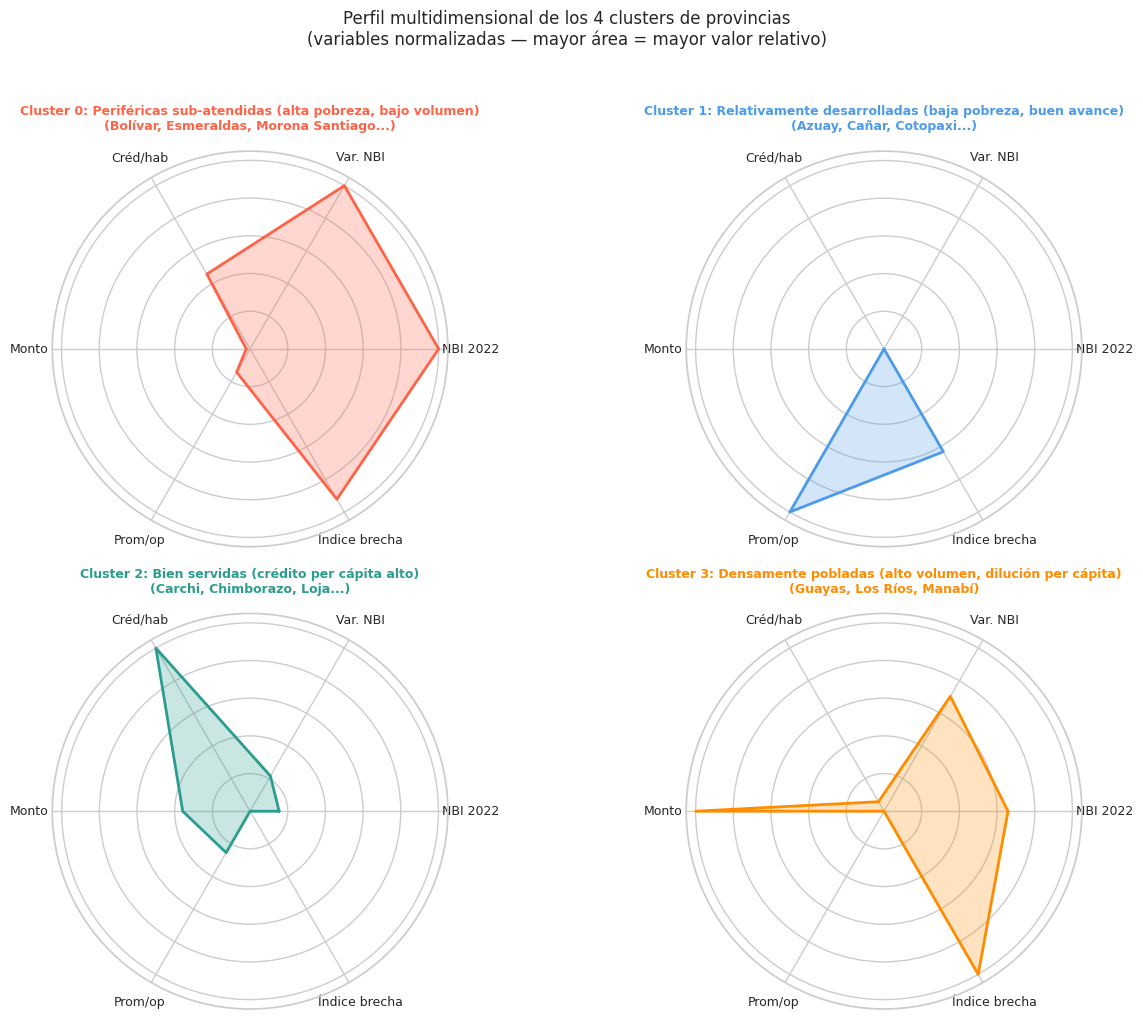

In [39]:
# ============================================================
# GRÁFICO RADAR: PERFIL MULTIDIMENSIONAL DE CADA CLUSTER
# Muestra las 6 variables a la vez para cada grupo
# ============================================================

from matplotlib.patches import FancyArrowPatch
import numpy as np

# Variables a mostrar en el radar (nombres cortos para el gráfico)
variables_radar = ["NBI 2022", "Var. NBI", "Créd/hab", "Monto", "Prom/op", "Índice brecha"]

# Normalizamos el perfil entre 0 y 1 para el radar
# (necesario para que todas las variables queden en la misma escala visual)
perfil_norm = perfil_clusters.copy()
for col in perfil_clusters.columns:
    col_min = perfil_clusters[col].min()
    col_max = perfil_clusters[col].max()
    if col_max != col_min:
        perfil_norm[col] = (perfil_clusters[col] - col_min) / (col_max - col_min)
    else:
        perfil_norm[col] = 0.5

# Número de variables y ángulos del radar
N = len(variables_radar)
# linspace genera N puntos equidistantes en el círculo (en radianes)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]  # cerramos el polígono repitiendo el primer ángulo

fig, axes = plt.subplots(2, 2, figsize=(13, 10),
                          subplot_kw=dict(polar=True))  # polar=True para gráfico circular
axes = axes.flatten()  # convertimos la matriz 2x2 en lista de 4 ejes

for idx, cluster_id in enumerate(sorted(perfil_norm.index)):
    ax = axes[idx]
    valores = perfil_norm.loc[cluster_id].tolist()
    valores += valores[:1]  # cerramos el polígono

    color = list(colores_cluster.values())[idx]

    # Dibujamos el área rellena del radar
    ax.fill(angulos, valores, color=color, alpha=0.25)
    # Dibujamos el contorno del radar
    ax.plot(angulos, valores, color=color, linewidth=2)

    # Etiquetas de cada eje
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(variables_radar, fontsize=9)

    # Eliminamos las etiquetas numéricas del radio (no son interpretables sin contexto)
    ax.set_yticklabels([])

    # Título con el nombre del cluster y las provincias
    provincias_cluster = df_cruce[df_cruce["cluster"] == cluster_id]["DPA_DESPRO"].tolist()
    ax.set_title(
        f"Cluster {cluster_id}: {nombres_clusters[cluster_id].replace(chr(10), ' ')}\n"
        f"({', '.join(provincias_cluster[:3])}{'...' if len(provincias_cluster) > 3 else ''})",
        fontsize=9, pad=15, color=color, fontweight="bold"
    )

plt.suptitle(
    "Perfil multidimensional de los 4 clusters de provincias\n"
    "(variables normalizadas — mayor área = mayor valor relativo)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# ANÁLISIS INTERNO DEL CLUSTER 2: ¿ES CHIMBORAZO REALMENTE
# "BIEN SERVIDA" O HAY HETEROGENEIDAD INTERNA?
# ============================================================

# Revisamos los cantones de Chimborazo en el dataset MAG
# para ver si el crédito llega a los cantones más pobres (Guamote, Alausí)
# o se concentra en Riobamba

chimborazo_cantones = df_mag[
    df_mag["DPA_DESPRO"] == "Chimborazo"
].groupby("DPA_DESCAN").agg(
    monto_total=("CP_VALOR_USD", "sum"),
    num_operaciones=("CP_NUM_OPERACIONES", "sum")
).reset_index()

chimborazo_cantones["monto_millones"] = (
    chimborazo_cantones["monto_total"] / 1_000_000
).round(2)

chimborazo_cantones["promedio_op"] = (
    chimborazo_cantones["monto_total"] /
    chimborazo_cantones["num_operaciones"]
).round(0)

chimborazo_cantones = chimborazo_cantones.sort_values(
    "monto_millones", ascending=False
)

print("=== CRÉDITO POR CANTÓN EN CHIMBORAZO (2013-2025) ===")
print("(Guamote y Alausí son los cantones con mayor pobreza indígena)\n")
print(chimborazo_cantones[["DPA_DESCAN", "monto_millones",
                            "num_operaciones", "promedio_op"]].to_string(index=False))

=== CRÉDITO POR CANTÓN EN CHIMBORAZO (2013-2025) ===
(Guamote y Alausí son los cantones con mayor pobreza indígena)

DPA_DESCAN  monto_millones  num_operaciones  promedio_op
    Alausí           81.19            19068       4258.0
  Riobamba           67.80            15405       4401.0
   Guamote           42.81            14126       3031.0
     Guano           30.52             6776       4505.0
   Chunchi           30.09             5562       5410.0
   Cumandá           22.99             2797       8220.0
     Colta           22.32             7004       3187.0
    Chambo           13.03             1681       7750.0
Pallatanga           12.77             2893       4414.0
    Penipe            9.48             1179       8043.0


In [41]:
# Cruzamos con el NBI cantonal para ver la distribución interna
nbi_chimborazo = df_nbi[df_nbi["provincia"] == "Chimborazo"][
    ["canton", "pct_nbi_2022", "pct_nbi_2010", "variacion_pct"]
].sort_values("pct_nbi_2022", ascending=False)

print("=== NBI POR CANTÓN EN CHIMBORAZO ===")
print(nbi_chimborazo.to_string(index=False))

=== NBI POR CANTÓN EN CHIMBORAZO ===
    canton  pct_nbi_2022  pct_nbi_2010  variacion_pct
   Guamote         0.885         0.955          -0.07
     Colta         0.813         0.930          -0.12
    Alausí         0.742         0.866          -0.12
Pallatanga         0.648         0.848          -0.20
   Chunchi         0.539         0.746          -0.21
     Guano         0.494         0.809          -0.31
    Penipe         0.491         0.736          -0.25
    Chambo         0.373         0.698          -0.32
   Cumandá         0.362         0.685          -0.32
  Riobamba         0.253         0.464          -0.21


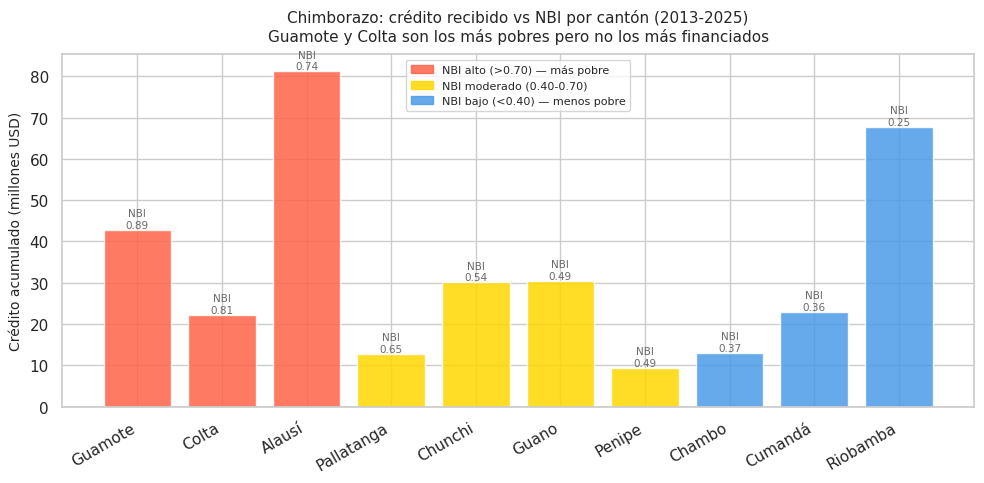


⚠ HALLAZGO: dentro de Chimborazo, los cantones más pobres
(Guamote NBI=0.885, Colta NBI=0.813) no son los más financiados.
Esto sugiere que la heterogeneidad interna provincial es un
problema adicional que el análisis a nivel cantón revelaría.


In [42]:
# ============================================================
# GRÁFICO: CHIMBORAZO — CRÉDITO vs NBI POR CANTÓN
# Evidencia de heterogeneidad interna
# ============================================================

# Cruzamos crédito y NBI a nivel cantonal para Chimborazo
chim_cruce = pd.merge(
    chimborazo_cantones,
    nbi_chimborazo,
    left_on="DPA_DESCAN",    # nombre del cantón en MAG
    right_on="canton",       # nombre del cantón en NBI
    how="inner"
).sort_values("pct_nbi_2022", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

# Coloreamos por nivel de NBI: más rojo = más pobre
colores_chim = [
    "tomato" if nbi > 0.7 else
    "gold" if nbi > 0.4 else
    "#4C9BE8"
    for nbi in chim_cruce["pct_nbi_2022"]
]

bars = ax.bar(
    chim_cruce["canton"],
    chim_cruce["monto_millones"],
    color=colores_chim,
    alpha=0.85,
    edgecolor="white"
)

# Añadimos el NBI encima de cada barra
for i, row in enumerate(chim_cruce.itertuples()):
    ax.text(
        i,
        row.monto_millones + 0.5,    # justo encima de la barra
        f"NBI\n{row.pct_nbi_2022:.2f}",
        ha="center",
        fontsize=7.5,
        color="dimgray"
    )

from matplotlib.patches import Patch
leyenda = [
    Patch(color="tomato", alpha=0.85, label="NBI alto (>0.70) — más pobre"),
    Patch(color="gold", alpha=0.85, label="NBI moderado (0.40-0.70)"),
    Patch(color="#4C9BE8", alpha=0.85, label="NBI bajo (<0.40) — menos pobre"),
]
ax.legend(handles=leyenda, fontsize=8)

ax.set_ylabel("Crédito acumulado (millones USD)", fontsize=10)
ax.set_title(
    "Chimborazo: crédito recibido vs NBI por cantón (2013-2025)\n"
    "Guamote y Colta son los más pobres pero no los más financiados",
    fontsize=11, pad=10
)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\n⚠ HALLAZGO: dentro de Chimborazo, los cantones más pobres")
print("(Guamote NBI=0.885, Colta NBI=0.813) no son los más financiados.")
print("Esto sugiere que la heterogeneidad interna provincial es un")
print("problema adicional que el análisis a nivel cantón revelaría.")

**ANÁLISIS ESPACIAL**

In [43]:
# ============================================================
# PASO 6: ANÁLISIS ESPACIAL — INSTALACIÓN Y CARGA DE GEOMETRÍAS
# ============================================================

# Instalamos las librerías necesarias para mapas
# geopandas: maneja datos geográficos (shapefiles, polígonos)
# mapclassify: clasifica datos para mapas coropléticos
!pip install geopandas mapclassify --quiet

print("✅ Librerías de mapas instaladas")

✅ Librerías de mapas instaladas


In [44]:
# ============================================================
# CARGA DEL GEOJSON CANTONAL Y DISOLUCIÓN A NIVEL PROVINCIAL
# El archivo ecuador.geojson tiene 224 cantones — lo disolvemos
# por provincia para obtener los 24 polígonos provinciales
# con geometrías correctas (incluida Guayas)
# ============================================================

import geopandas as gpd
from shapely.validation import make_valid

# Leemos el GeoJSON cantonal que subiste
ecuador_cantonal = gpd.read_file("ecuador.geojson")
print(f"Cantones cargados: {len(ecuador_cantonal)}")
print(f"Columna de provincia: DPA_DESPRO")

# Disolvemos (unimos) los cantones por provincia
# dissolve() une todos los polígonos de cantones de una misma provincia
# en un solo polígono provincial
ecuador_prov = ecuador_cantonal.dissolve(by="DPA_DESPRO", as_index=False)
print(f"Provincias tras dissolve: {len(ecuador_prov)}")

# Reparamos geometrías por si acaso
ecuador_prov["geometry"] = ecuador_prov["geometry"].apply(make_valid)

# Normalizamos los nombres a formato título (de MAYÚSCULAS a Título)
# y corregimos tildes para que coincidan con nuestros datos
mapeo_nombres = {
    "AZUAY"                    : "Azuay",
    "BOLIVAR"                  : "Bolívar",
    "CAÐAR"                    : "Cañar",   # carácter especial en el archivo
    "CAÑAR"                    : "Cañar",
    "CARCHI"                   : "Carchi",
    "CHIMBORAZO"               : "Chimborazo",
    "COTOPAXI"                 : "Cotopaxi",
    "EL ORO"                   : "El Oro",
    "ESMERALDAS"               : "Esmeraldas",
    "GALAPAGOS"                : "Galápagos",
    "GUAYAS"                   : "Guayas",
    "IMBABURA"                 : "Imbabura",
    "LOJA"                     : "Loja",
    "LOS RIOS"                 : "Los Ríos",
    "MANABI"                   : "Manabí",
    "MORONA SANTIAGO"          : "Morona Santiago",
    "NAPO"                     : "Napo",
    "ORELLANA"                 : "Orellana",
    "PASTAZA"                  : "Pastaza",
    "PICHINCHA"                : "Pichincha",
    "SANTA ELENA"              : "Santa Elena",
    "SANTO DOMINGO DE LOS TSACHILAS": "Santo Domingo De Los Tsáchilas",
    "SUCUMBIOS"                : "Sucumbíos",
    "TUNGURAHUA"               : "Tungurahua",
    "ZAMORA CHINCHIPE"         : "Zamora Chinchipe",
}

ecuador_prov["province"] = ecuador_prov["DPA_DESPRO"].map(mapeo_nombres)

# Verificamos que no quedó ningún nombre sin mapear
sin_mapear = ecuador_prov[ecuador_prov["province"].isna()]["DPA_DESPRO"].tolist()
print(f"\nSin mapear: {sin_mapear}")

# Verificamos Guayas
guayas = ecuador_prov[ecuador_prov["province"] == "Guayas"].iloc[0]
print(f"\nGuayas — válida: {guayas.geometry.is_valid}")
print(f"Guayas — área: {guayas.geometry.area:.4f}")
print(f"Guayas — tipo: {guayas.geometry.geom_type}")

# Asignamos como el GeoDataFrame principal a usar en los mapas
ecuador = ecuador_prov.copy()
print(f"\n✅ GeoDataFrame provincial listo con {len(ecuador)} provincias")

Cantones cargados: 224
Columna de provincia: DPA_DESPRO
Provincias tras dissolve: 25

Sin mapear: ['ZONA NO DELIMITADA']

Guayas — válida: True
Guayas — área: 1.2456
Guayas — tipo: MultiPolygon

✅ GeoDataFrame provincial listo con 25 provincias


In [45]:
# Nombres en el GeoJSON
nombres_geo = set(ecuador["province"].tolist())

# Nombres en nuestro dataset de cruce
nombres_datos = set(df_cruce["DPA_DESPRO"].tolist())

print("=== EN GEOJSON PERO NO EN DATOS ===")
print(nombres_geo - nombres_datos)

print("\n=== EN DATOS PERO NO EN GEOJSON ===")
print(nombres_datos - nombres_geo)

=== EN GEOJSON PERO NO EN DATOS ===
{nan}

=== EN DATOS PERO NO EN GEOJSON ===
set()


In [46]:
# ============================================================
# MERGE DEL GEOJSON CON NUESTROS DATOS
# ============================================================

# Eliminamos la fila con province = NaN (zona no delimitada)
# que quedó sin mapear en el dissolve
ecuador = ecuador[ecuador["province"].notna()].copy()
print(f"Provincias tras eliminar NaN: {len(ecuador)}")

# Unimos el GeoJSON con el dataset de cruce (clustering + scoring + NBI)
# left_on y right_on indican la columna de unión en cada dataset
gdf = ecuador.merge(
    df_cruce,                          # dataset con clustering, scoring y NBI
    left_on="province",                # columna de provincia en el GeoJSON
    right_on="DPA_DESPRO",            # columna de provincia en nuestros datos
    how="left"                         # conservamos todas las provincias del mapa
)

print("✅ Merge realizado")
print("Filas en el GeoDataFrame:", len(gdf))
print("Valores nulos en indice_brecha:", gdf["indice_brecha"].isna().sum())
print("Valores nulos en cluster:", gdf["cluster"].isna().sum())

Provincias tras eliminar NaN: 24
✅ Merge realizado
Filas en el GeoDataFrame: 24
Valores nulos en indice_brecha: 0
Valores nulos en cluster: 0


In [47]:
# ============================================================
# CORRECCIÓN: usamos la columna correcta después del merge
# ============================================================

# Verificamos los nombres de columnas reales después del merge
print("Columnas en gdf:", [c for c in gdf.columns if 'prov' in c.lower()
                             or 'nombre' in c.lower() or 'std' in c.lower()])

# Identificamos la columna de nombre de provincia a usar para etiquetas
# En el GeoJSON de pabl-o-ce la columna se llama "province"
col_nombre = "province"
print("Columna de nombre a usar:", col_nombre)
print("\nMuestra:")
print(gdf[[col_nombre, "indice_brecha", "cluster"]].head(10).to_string())

Columnas en gdf: ['DPA_PROVIN', 'province', 'provincia_std', 'provincia', 'pob_total_provincia', 'cluster_nombre']
Columna de nombre a usar: province

Muestra:
     province  indice_brecha  cluster
0       Azuay          0.559        1
1     Bolívar          0.633        0
2      Carchi          0.290        2
3       Cañar          0.605        1
4  Chimborazo          0.532        2
5    Cotopaxi          0.626        1
6      El Oro          0.646        1
7  Esmeraldas          0.781        0
8   Galápagos          0.573        1
9      Guayas          0.702        3


In [48]:
# Recalculamos puntos representativos usando la columna correcta
def get_rep_point3(row):
    # Galápagos tiene islas dispersas — posición manual
    nombre = str(row.get(col_nombre, "")).strip()
    if "GAL" in nombre.upper():
        return (-90.80, -0.95)
    try:
        geom = row.geometry
        if not geom.is_empty:
            rp = geom.representative_point()
            if not rp.is_empty:
                return (rp.x, rp.y)
        bounds = geom.bounds
        return ((bounds[0]+bounds[2])/2, (bounds[1]+bounds[3])/2)
    except Exception:
        return None

puntos3 = gdf.apply(get_rep_point3, axis=1)
gdf["rep_x"] = puntos3.apply(lambda p: p[0] if p else None)
gdf["rep_y"] = puntos3.apply(lambda p: p[1] if p else None)

print("✅ Puntos calculados")
print(gdf[[col_nombre, "rep_x", "rep_y"]].to_string(index=False))

✅ Puntos calculados
                      province      rep_x     rep_y
                         Azuay -78.953632 -3.063498
                       Bolívar -79.057213 -1.675620
                        Carchi -77.949399  0.776976
                         Cañar -78.997133 -2.523647
                    Chimborazo -78.749088 -1.997004
                      Cotopaxi -78.604159 -0.775636
                        El Oro -79.891067 -3.469160
                    Esmeraldas -79.280926  0.657248
                     Galápagos -90.800000 -0.950000
                        Guayas -79.925553 -1.949608
                      Imbabura -78.324765  0.498538
                          Loja -79.991741 -4.036676
                      Los Ríos -79.537842 -1.336368
                        Manabí -80.101604 -0.789673
               Morona Santiago -77.496596 -2.517581
                          Napo -77.952160 -0.608577
                      Orellana -76.223648 -0.804615
                       Pastaza -76.822912 -1

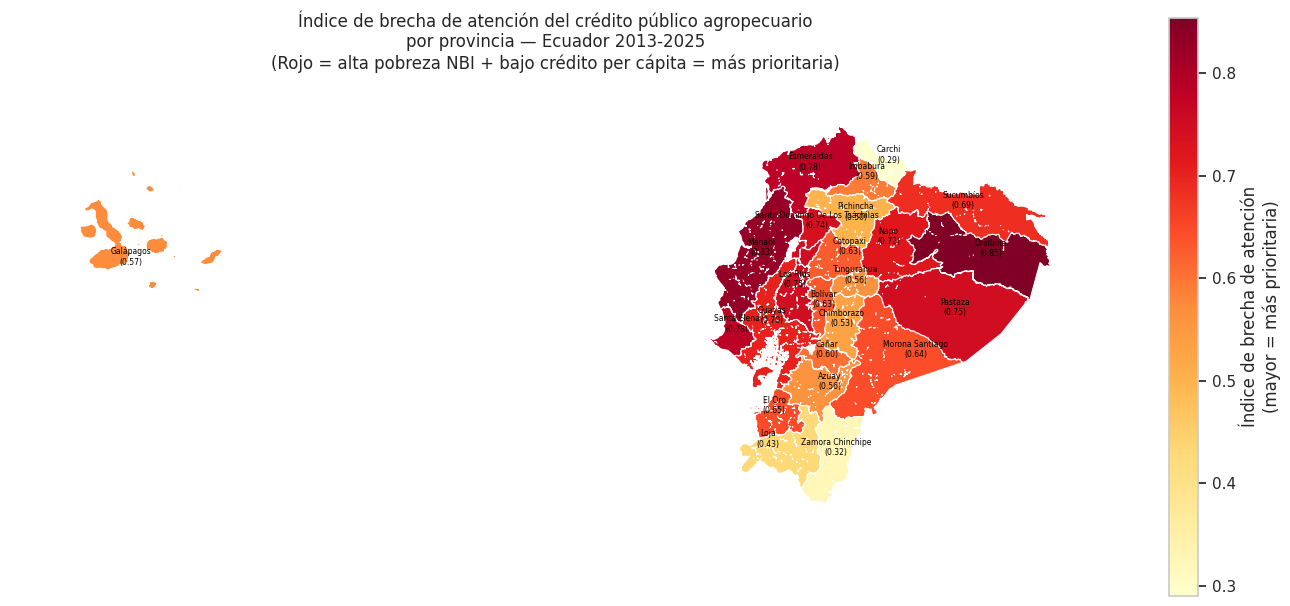

✅ Mapa 1 guardado


In [49]:
# ============================================================
# MAPA 1 DEFINITIVO — ÍNDICE DE BRECHA
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

gdf.plot(
    column="indice_brecha",
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Índice de brecha de atención\n(mayor = más prioritaria)",
        "orientation": "vertical",
        "shrink": 0.6
    },
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

# Cambiado: gdf2 → gdf
for _, row in gdf.iterrows():
    if pd.notna(row.get("indice_brecha")) and pd.notna(row["rep_x"]):
        ax.annotate(
            f"{row[col_nombre]}\n({row['indice_brecha']:.2f})",
            xy=(row["rep_x"], row["rep_y"]),
            ha="center", fontsize=5.5, color="black"
        )

ax.set_title(
    "Índice de brecha de atención del crédito público agropecuario\n"
    "por provincia — Ecuador 2013-2025\n"
    "(Rojo = alta pobreza NBI + bajo crédito per cápita = más prioritaria)",
    fontsize=12, pad=15
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mapa_indice_brecha.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Mapa 1 guardado")

/tmp/ipykernel_5000/473596966.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8,
/tmp/ipykernel_5000/473596966.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower left", fontsize=8,


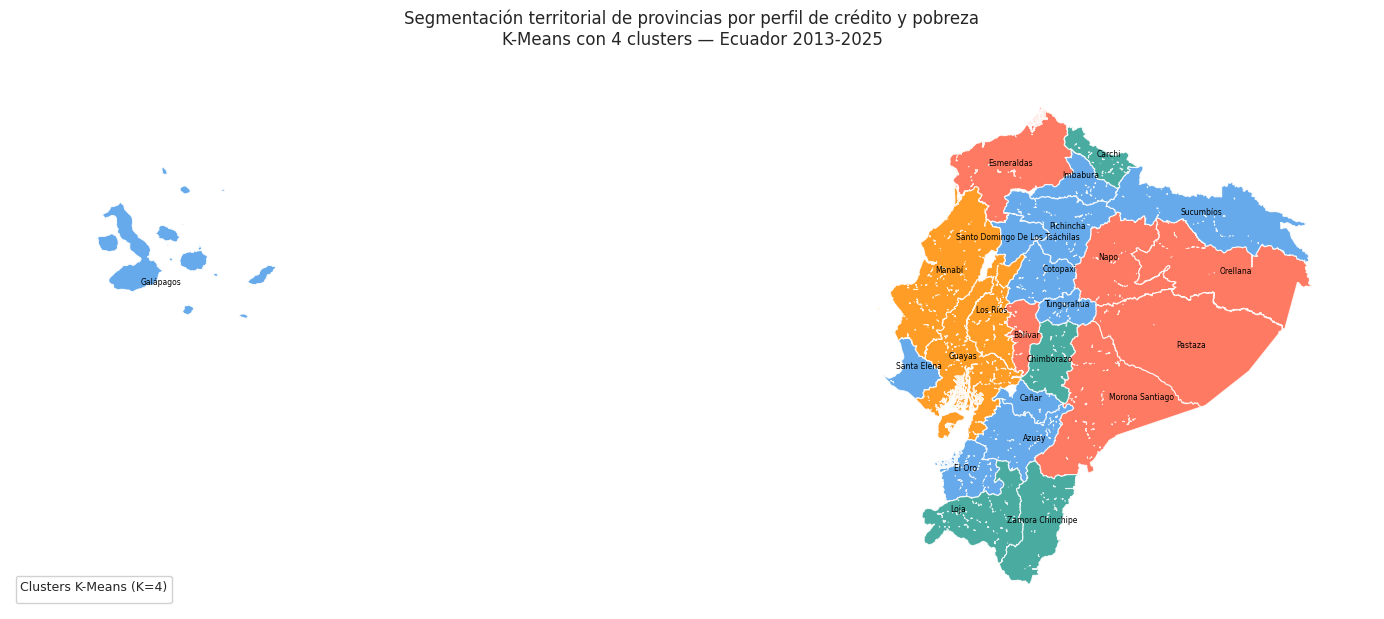

✅ Mapa 2 guardado


In [50]:
# ============================================================
# MAPA 2 DEFINITIVO — CLUSTERS
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

colores_mapa = {
    0: ("tomato",     "Cluster 0: Periféricas sub-atendidas"),
    1: ("#4C9BE8",    "Cluster 1: Relativamente desarrolladas"),
    2: ("#2A9D8F",    "Cluster 2: Bien servidas"),
    3: ("darkorange", "Cluster 3: Densamente pobladas")
}

# Cambiado: gdf2 → gdf
for cluster_id, (color, etiqueta) in colores_mapa.items():
    subset = gdf[gdf["cluster"] == cluster_id]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor="white",
                    linewidth=0.8, label=etiqueta, alpha=0.85)

# Zona no delimitada y sin datos en gris
# Cambiado: gdf2 → gdf
sin_cluster = gdf[gdf["cluster"].isna()]
if len(sin_cluster) > 0:
    sin_cluster.plot(ax=ax, color="lightgrey",
                     edgecolor="white", linewidth=0.8,
                     label="Sin datos / Zona no delimitada")

# Cambiado: gdf2 → gdf
for _, row in gdf.iterrows():
    if pd.notna(row["rep_x"]) and pd.notna(row.get(col_nombre)):
        ax.annotate(
            row[col_nombre],
            xy=(row["rep_x"], row["rep_y"]),
            ha="center", fontsize=5.5, color="black"
        )

ax.legend(loc="lower left", fontsize=8,
          title="Clusters K-Means (K=4)",
          title_fontsize=9, framealpha=0.9)
ax.set_title(
    "Segmentación territorial de provincias por perfil de crédito y pobreza\n"
    "K-Means con 4 clusters — Ecuador 2013-2025",
    fontsize=12, pad=15
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("mapa_clusters.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Mapa 2 guardado")

**INTERPRETABILIDAD CON SHAP**

In [51]:
# ============================================================
# PASO 7: INTERPRETABILIDAD CON SHAP
# Explicamos qué variables impulsan el índice de brecha
# de cada provincia — esto convierte el modelo en algo
# que puede explicarse a un equipo de negocio
# ============================================================

# Instalamos SHAP
!pip install shap --quiet

import shap
from sklearn.ensemble import GradientBoostingRegressor

print("✅ SHAP instalado")

✅ SHAP instalado


In [52]:
# ============================================================
# ENTRENAMOS UN MODELO SUPERVISADO PARA APLICAR SHAP
# SHAP funciona mejor con modelos supervisados que con clustering
# Usamos el índice de brecha como variable objetivo (Y)
# y las variables originales como predictores (X)
# ============================================================

# Variables predictoras (X): las mismas que usamos en el clustering
# pero SIN el índice de brecha (que es lo que queremos explicar)
X = df_cruce[[
    "nbi_2022_pond",      # nivel de pobreza actual
    "variacion_nbi",      # mejora de pobreza 2010-2022
    "credito_per_capita", # crédito per cápita recibido
    "monto_millones",     # volumen total de crédito
    "promedio_op"         # tamaño promedio del crédito
]].copy()

# Variable objetivo (Y): el índice de brecha que queremos explicar
y = df_cruce["indice_brecha"]

# Nombres legibles para los gráficos de SHAP
nombres_variables = [
    "NBI 2022 (pobreza)",
    "Variación NBI 2010-2022",
    "Crédito per cápita",
    "Monto total (M USD)",
    "Promedio por operación"
]

# Entrenamos un Gradient Boosting Regressor
# Este modelo es ideal para SHAP porque captura relaciones no lineales
# random_state=42 para reproducibilidad
# n_estimators=200: número de árboles
# max_depth=3: profundidad máxima de cada árbol (evita sobreajuste)
modelo_shap = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    random_state=42,
    learning_rate=0.05  # tasa de aprendizaje conservadora
)

# Ajustamos el modelo (aprende la relación entre X e Y)
modelo_shap.fit(X, y)

# Evaluamos qué tan bien predice el índice de brecha
from sklearn.metrics import r2_score
y_pred = modelo_shap.predict(X)
r2 = r2_score(y, y_pred)
print(f"R² del modelo: {r2:.3f}")
print("(Un R² > 0.85 indica que el modelo captura bien el índice de brecha)")

R² del modelo: 1.000
(Un R² > 0.85 indica que el modelo captura bien el índice de brecha)


In [53]:
# ============================================================
# CALCULAMOS LOS VALORES SHAP
# SHAP descompone la predicción de cada provincia en
# la contribución de cada variable
# ============================================================

# Creamos el explicador SHAP para modelos de árbol
# TreeExplainer es el más eficiente para GradientBoosting
explainer = shap.TreeExplainer(modelo_shap)

# Calculamos los valores SHAP para todas las provincias
# shap_values[i][j] = contribución de la variable j a la predicción de la provincia i
shap_values = explainer.shap_values(X)

print("✅ Valores SHAP calculados")
print("Dimensiones:", shap_values.shape)
print("(24 provincias × 5 variables)")

✅ Valores SHAP calculados
Dimensiones: (24, 5)
(24 provincias × 5 variables)


In [54]:
# ============================================================
# CALCULAMOS LA IMPORTANCIA GLOBAL SHAP
# Promedio del valor absoluto de los SHAP values por variable
# ============================================================

importancia_shap = pd.DataFrame({
    "variable": nombres_variables,
    # abs() toma el valor absoluto — importa la magnitud, no el signo
    # mean(axis=0) promedia las 24 provincias para cada variable
    "importancia_media": np.abs(shap_values).mean(axis=0)
}).sort_values("importancia_media", ascending=True)

print("=== IMPORTANCIA GLOBAL DE VARIABLES (SHAP) ===")
print(importancia_shap.to_string(index=False))

=== IMPORTANCIA GLOBAL DE VARIABLES (SHAP) ===
               variable  importancia_media
 Promedio por operación           0.001474
Variación NBI 2010-2022           0.006575
    Monto total (M USD)           0.007957
     Crédito per cápita           0.073608
     NBI 2022 (pobreza)           0.077433


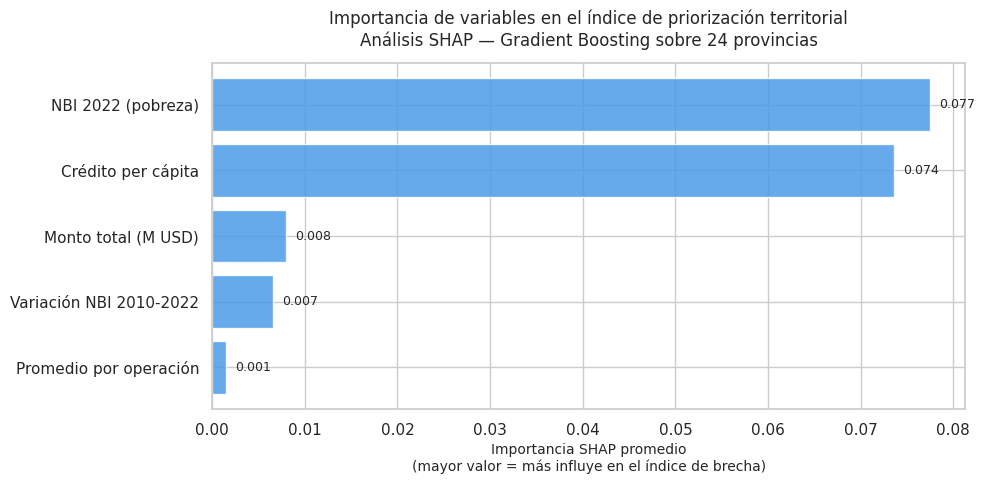

In [55]:
# ============================================================
# GRÁFICO SHAP: IMPORTANCIA GLOBAL DE VARIABLES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    importancia_shap["variable"],
    importancia_shap["importancia_media"],
    color="#4C9BE8",
    alpha=0.85,
    edgecolor="white"
)

for i, row in enumerate(importancia_shap.itertuples()):
    ax.text(
        row.importancia_media + 0.001,
        i,
        f"{row.importancia_media:.3f}",
        va="center",
        fontsize=9
    )

ax.set_xlabel(
    "Importancia SHAP promedio\n(mayor valor = más influye en el índice de brecha)",
    fontsize=10
)
ax.set_title(
    "Importancia de variables en el índice de priorización territorial\n"
    "Análisis SHAP — Gradient Boosting sobre 24 provincias",
    fontsize=12, pad=12
)
plt.tight_layout()
plt.savefig("shap_importancia_global.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

Top 3 provincias más prioritarias:
  Orellana: 0.854
  Manabí: 0.827
  Santa Elena: 0.782


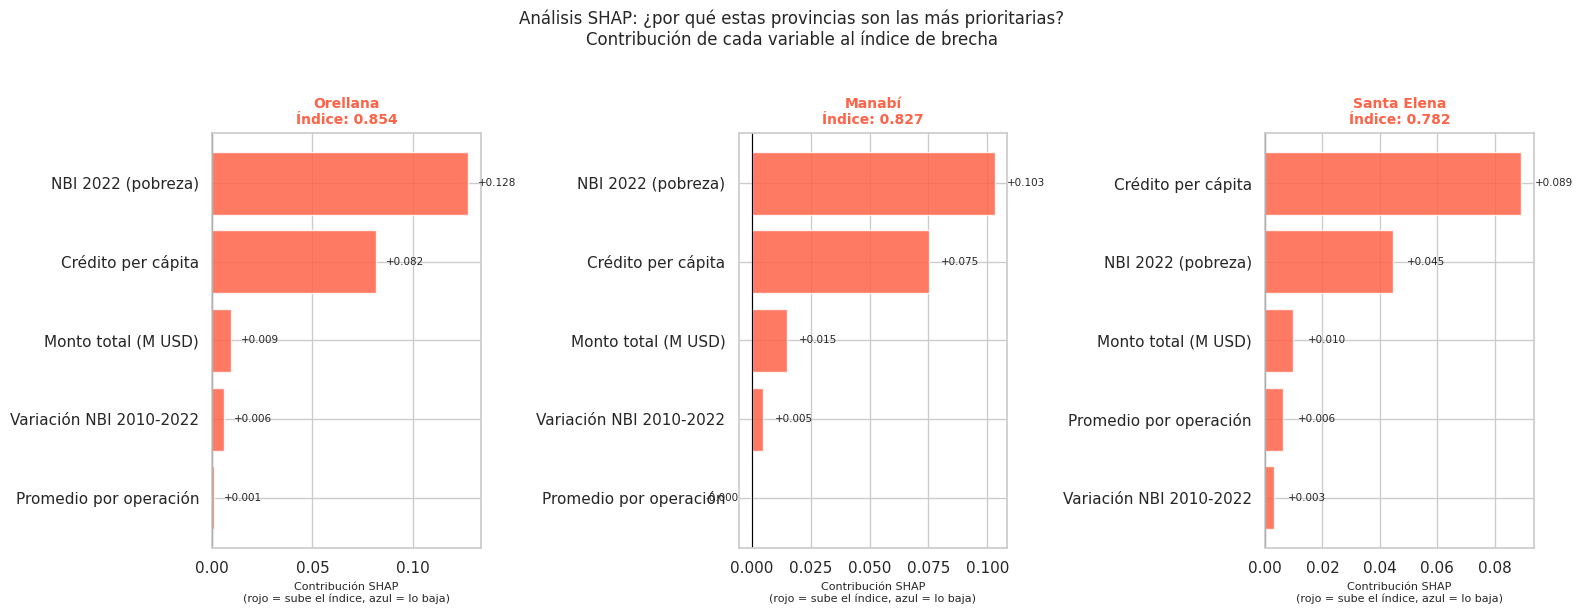

✅ Gráfico SHAP por provincia guardado


In [56]:
# ============================================================
# GRÁFICO SHAP: CONTRIBUCIÓN POR PROVINCIA (WATERFALL)
# Muestra cómo cada variable empuja el índice hacia arriba
# o hacia abajo para las 3 provincias más prioritarias
# ============================================================

# Identificamos los índices de las 3 provincias más prioritarias
top3_idx = df_cruce.nlargest(3, "indice_brecha").index.tolist()
top3_nombres = df_cruce.loc[top3_idx, "DPA_DESPRO"].tolist()
top3_indices = df_cruce.loc[top3_idx, "indice_brecha"].tolist()

print("Top 3 provincias más prioritarias:")
for n, v in zip(top3_nombres, top3_indices):
    print(f"  {n}: {v:.3f}")

# Creamos el gráfico de barras SHAP por provincia manualmente
# para las 3 más prioritarias — mostramos la contribución de cada variable
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax_idx, (prov_idx, nombre, indice) in enumerate(
    zip(top3_idx, top3_nombres, top3_indices)
):
    ax = axes[ax_idx]

    # Obtenemos los valores SHAP de esta provincia
    # Convertimos el índice del DataFrame al índice posicional para SHAP
    pos_idx = df_cruce.index.get_loc(prov_idx)
    shap_prov = shap_values[pos_idx]

    # Creamos DataFrame de contribuciones para esta provincia
    contrib = pd.DataFrame({
        "variable": nombres_variables,
        "shap_value": shap_prov,
        "valor_real": X.iloc[pos_idx].values
    }).sort_values("shap_value", ascending=True)

    # Colores: positivo (empuja el índice hacia arriba) = rojo
    #          negativo (empuja el índice hacia abajo) = azul
    colores = ["tomato" if v > 0 else "#4C9BE8"
               for v in contrib["shap_value"]]

    ax.barh(
        contrib["variable"],
        contrib["shap_value"],
        color=colores,
        alpha=0.85,
        edgecolor="white"
    )

    # Línea vertical en 0 para referencia
    ax.axvline(x=0, color="black", linewidth=0.8)

    # Etiqueta con el valor SHAP y el valor real de la variable
    for i, row in enumerate(contrib.itertuples()):
        signo = "+" if row.shap_value > 0 else ""
        ax.text(
            row.shap_value + (0.005 if row.shap_value >= 0 else -0.005),
            i,
            f"{signo}{row.shap_value:.3f}",
            va="center",
            ha="left" if row.shap_value >= 0 else "right",
            fontsize=7.5
        )

    ax.set_title(
        f"{nombre}\nÍndice: {indice:.3f}",
        fontsize=10, color="tomato", fontweight="bold"
    )
    ax.set_xlabel("Contribución SHAP\n(rojo = sube el índice, azul = lo baja)",
                  fontsize=8)

plt.suptitle(
    "Análisis SHAP: ¿por qué estas provincias son las más prioritarias?\n"
    "Contribución de cada variable al índice de brecha",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("shap_top3_provincias.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Gráfico SHAP por provincia guardado")

In [57]:
# ============================================================
# TABLA SHAP PARA LA MEMORIA
# Muestra la contribución de cada variable para las 6 provincias
# más prioritarias — lista para copiar en la memoria
# ============================================================

print("=== CONTRIBUCIONES SHAP — TOP 6 PROVINCIAS MÁS PRIORITARIAS ===\n")
print(f"{'Provincia':<35} {'NBI':>8} {'Var.NBI':>8} {'Créd/cap':>9} "
      f"{'Monto':>8} {'Prom/op':>8} {'TOTAL':>8}")
print("-" * 90)

top6_idx = df_cruce.nlargest(6, "indice_brecha").index.tolist()

for prov_idx in top6_idx:
    nombre = df_cruce.loc[prov_idx, "DPA_DESPRO"]
    indice = df_cruce.loc[prov_idx, "indice_brecha"]
    pos_idx = df_cruce.index.get_loc(prov_idx)
    sv = shap_values[pos_idx]

    print(f"{nombre:<35} {sv[0]:>+8.3f} {sv[1]:>+8.3f} {sv[2]:>+9.3f} "
          f"{sv[3]:>+8.3f} {sv[4]:>+8.3f} {indice:>8.3f}")

=== CONTRIBUCIONES SHAP — TOP 6 PROVINCIAS MÁS PRIORITARIAS ===

Provincia                                NBI  Var.NBI  Créd/cap    Monto  Prom/op    TOTAL
------------------------------------------------------------------------------------------
Orellana                              +0.128   +0.006    +0.082   +0.009   +0.001    0.854
Manabí                                +0.103   +0.005    +0.075   +0.015   -0.000    0.827
Santa Elena                           +0.045   +0.003    +0.089   +0.010   +0.006    0.782
Esmeraldas                            +0.112   +0.009    +0.040   -0.007   -0.001    0.781
Los Ríos                              +0.089   +0.003    +0.005   +0.020   +0.001    0.747
Pastaza                               +0.042   +0.003    +0.077   -0.004   -0.000    0.747
